So after i recently found out my database was corrupted, i had to refetch all statistics from the games, as they were in the way for the streamlit building, and model training, as i was missing some valuable data.

I will therefor now, before we start, make sure we have all the relevant data for the feature selcetion, and feature engineering.

First cell we will load the DB into the file, and we will have a view of the data

In [180]:
# ✅ Cell 1: Load and inspect SportMonks DB content

import sqlite3
import pandas as pd

# Connect to your DB
db_path = "db_sportmonks.db"
conn = sqlite3.connect(db_path)

# List all tables
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
)
print("📦 Tables in database:")
display(tables)

# Show row counts for key tables
key_tables = [
    "fixtures", "statistics", "player_statistics", "odds", 
    "teams", "players", "seasons", "leagues"
]

print("🔍 Table row counts:")
row_counts = []
for table in key_tables:
    try:
        count = pd.read_sql(f"SELECT COUNT(*) AS count FROM {table}", conn)['count'].iloc[0]
        row_counts.append((table, count))
    except:
        row_counts.append((table, "❌ Error"))

display(pd.DataFrame(row_counts, columns=["table", "rows"]))

# Preview some data from core tables
print("📊 Sample fixture results:")
display(pd.read_sql("SELECT id, league_id, season_id, home_team_id, away_team_id, score_home, score_away, starting_at FROM fixtures WHERE score_home IS NOT NULL ORDER BY starting_at DESC LIMIT 5", conn))

print("📈 Sample game statistics:")
display(pd.read_sql("SELECT * FROM statistics WHERE value IS NOT NULL LIMIT 5", conn))

print("👟 Sample player statistics:")
display(pd.read_sql("SELECT * FROM player_statistics WHERE value IS NOT NULL LIMIT 5", conn))

print("💸 Sample odds:")
display(pd.read_sql("SELECT * FROM odds LIMIT 5", conn))

conn.close()

📦 Tables in database:


,name
0,bookmakers
1,cards
2,checkpoint
3,cities
4,coaches
5,commentaries
6,continents
7,countries
8,evaluation
9,events


🔍 Table row counts:


,table,rows
0,fixtures,155552
1,statistics,538336
2,player_statistics,31282644
3,odds,❌ Error
4,teams,2508
5,players,75765
6,seasons,531
7,leagues,27


📊 Sample fixture results:


...

,id,fixture_id,team_id,type,type_id,value,updated_at,raw
0,19129777_None_None,19129777,12038,None,None,50,2025-05-20T20:13:28.042225,"{""id"": 406530160, ""fixture_id"": 19129777, ""typ..."
1,19135032_None_None,19135032,78,None,None,1,2025-05-20T20:13:28.042296,"{""id"": 406895322, ""fixture_id"": 19135032, ""typ..."
2,19136809_None_None,19136809,593,None,None,2,2025-05-20T20:13:28.042365,"{""id"": 403723344, ""fixture_id"": 19136809, ""typ..."
3,19136810_None_None,19136810,61,None,None,1,2025-05-20T20:13:28.042430,"{""id"": 403695980, ""fixture_id"": 19136810, ""typ..."
4,19136811_None_None,19136811,1459,None,None,2,2025-05-20T20:13:28.042488,"{""id"": 403944812, ""fixture_id"": 19136811, ""typ..."


👟 Sample player statistics:


,id,fixture_id,player_id,team_id,type,type_id,value,updated_at,raw
0,19135034_692_121,19135034,692,51,Turn Over,121,1,2025-05-21T12:16:09.973499,"{""id"": 1554502338, ""fixture_id"": 19135034, ""pl..."
1,19135034_97692_56,19135034,97692,29,Fouls,56,1,2025-05-21T12:16:09.975746,"{""id"": 1554563933, ""fixture_id"": 19135034, ""pl..."
2,19135034_37541456_96,19135034,37541456,51,Fouls Drawn,96,1,2025-05-21T12:16:09.975790,"{""id"": 1554563935, ""fixture_id"": 19135034, ""pl..."
3,19135034_37541456_106,19135034,37541456,51,Duels Won,106,1,2025-05-21T12:16:09.975933,"{""id"": 1554563936, ""fixture_id"": 19135034, ""pl..."
4,19145087_7698433_27269,19145087,7698433,618,Passes In Final Third,27269,2,2025-05-21T12:16:09.975956,"{""id"": 1551849093, ""fixture_id"": 19145087, ""pl..."


💸 Sample odds:


,id,fixture_id,bookmaker_id,market_id,label,odd_value,updated_at,raw
0,117314740794,19138512,38,1,Home,6.05,2025-05-11T11:11:27.929085,"{""id"": 117314740794, ""fixture_id"": 19138512, ""..."
1,117314740795,19138512,38,1,Draw,4.00,2025-05-11T11:11:27.929119,"{""id"": 117314740795, ""fixture_id"": 19138512, ""..."
2,117314740796,19138512,38,1,Away,1.59,2025-05-11T11:11:27.929096,"{""id"": 117314740796, ""fixture_id"": 19138512, ""..."
3,117315706427,19138512,38,6,Home,1.85,2025-05-11T11:11:27.936061,"{""id"": 117315706427, ""fixture_id"": 19138512, ""..."
4,117315706428,19138512,38,6,Away,1.79,2025-05-11T11:11:27.936070,"{""id"": 117315706428, ""fixture_id"": 19138512, ""..."


In [2]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("db_sportmonks.db")

# List all tables
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
)
print("✅ TABLES IN DATABASE:")
print(tables.to_string(index=False), end="\n\n")

# Row counts for each table
print("📊 ROW COUNTS PER TABLE:")
for table in tables['name']:
    try:
        count = pd.read_sql(f"SELECT COUNT(*) AS count FROM {table}", conn)['count'].iloc[0]
        print(f"{table:<30} {count}")
    except Exception as e:
        print(f"{table:<30} ❌ Error: {e}")

print("\n📌 SAMPLE DATA (FIRST 3 ROWS PER TABLE):\n")

for table in ["fixtures", "statistics", "player_statistics", "odds", "teams", "players"]:
    try:
        df = pd.read_sql(f"SELECT * FROM {table} LIMIT 3", conn)
        print(f"--- {table.upper()} ---")
        print(df.to_string(index=False))
        print()
    except Exception as e:
        print(f"⚠️ Failed to read table {table}: {e}")

conn.close()


✅ TABLES IN DATABASE:
                   name
             bookmakers
                  cards
             checkpoint
                 cities
                coaches
           commentaries
             continents
              countries
             evaluation
                 events
            expected_xg
           fixture_odds
     fixture_team_names
               fixtures
                 groups
                leagues
                lineups
                markets
                   news
                   odds
             odds_cache
        odds_checkpoint
              penalties
      player_statistics
                players
            predictions
     processed_fixtures
processed_fixtures_odds
               referees
                regions
                 rivals
                 rounds
              schedules
                seasons
        sqlite_sequence
                 squads
                 stages
              standings
             statistics
  statistics_check

As we see from this, we can identify that we are still missing bookmakers and markets as they are empty, but the odds still have valid market labels, like home win, draw and away win. We also see som statistics still have "None" in "type", but i think we will just filter these under feature processing.

Some basic EDA to begin with

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to DB
conn = sqlite3.connect("db_sportmonks.db")

# Load core fixture + result data
df_fixtures = pd.read_sql("""
    SELECT 
        f.id AS fixture_id,
        f.league_id,
        f.season_id,
        f.home_team_id,
        f.away_team_id,
        f.score_home,
        f.score_away,
        f.starting_at,
        l.name AS league_name,
        s.name AS season_name
    FROM fixtures f
    LEFT JOIN leagues l ON f.league_id = l.id
    LEFT JOIN seasons s ON f.season_id = s.id
    WHERE f.score_home IS NOT NULL AND f.score_away IS NOT NULL
""", conn)

# Convert dates
df_fixtures["starting_at"] = pd.to_datetime(df_fixtures["starting_at"])
df_fixtures["year"] = df_fixtures["starting_at"].dt.year

print("✅ Fixtures loaded:", df_fixtures.shape)
display(df_fixtures.head())

✅ Fixtures loaded: (154495, 11)


,fixture_id,league_id,season_id,home_team_id,away_team_id,score_home,score_away,starting_at,league_name,season_name,year
0,463,8,2,6,9,0,0,2010-08-14 11:45:00,Premier League,2010/2011,2010
1,464,8,3,8,26,1,0,2013-08-17 11:45:00,Premier League,2013/2014,2013
2,465,8,2,15,1,3,0,2010-08-14 14:00:00,Premier League,2010/2011,2010
3,466,8,3,19,15,1,3,2013-08-17 14:00:00,Premier League,2013/2014,2013
4,467,8,2,2,13,1,0,2010-08-14 14:00:00,Premier League,2010/2011,2010


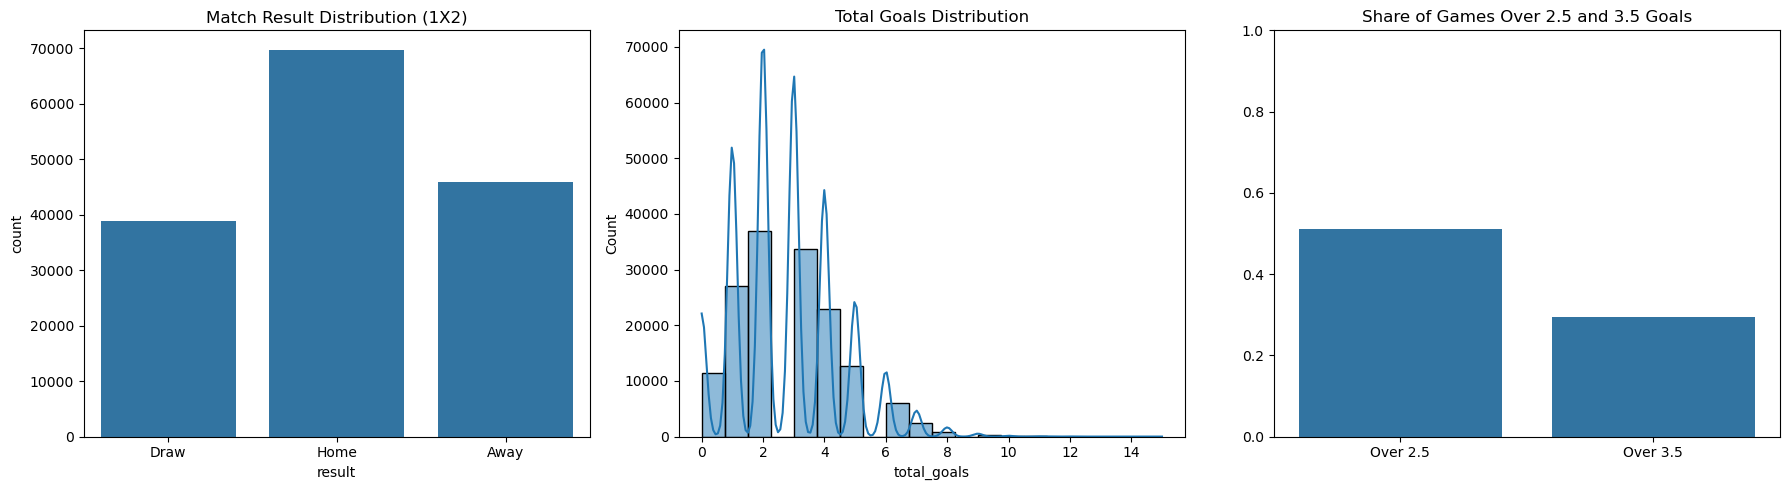

In [4]:
# Match Result (1X2)
def result_label(row):
    if row['score_home'] > row['score_away']:
        return 'Home'
    elif row['score_home'] < row['score_away']:
        return 'Away'
    else:
        return 'Draw'

df_fixtures["result"] = df_fixtures.apply(result_label, axis=1)

# Over/Under Targets
df_fixtures["total_goals"] = df_fixtures["score_home"] + df_fixtures["score_away"]
df_fixtures["over_2_5"] = df_fixtures["total_goals"] > 2.5
df_fixtures["over_3_5"] = df_fixtures["total_goals"] > 3.5

# Visualize
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_fixtures, x="result", ax=axs[0])
axs[0].set_title("Match Result Distribution (1X2)")

sns.histplot(df_fixtures["total_goals"], bins=20, kde=True, ax=axs[1])
axs[1].set_title("Total Goals Distribution")

sns.barplot(x=["Over 2.5", "Over 3.5"], 
            y=[df_fixtures["over_2_5"].mean(), df_fixtures["over_3_5"].mean()], ax=axs[2])
axs[2].set_title("Share of Games Over 2.5 and 3.5 Goals")
axs[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

noew we'll show it with cards

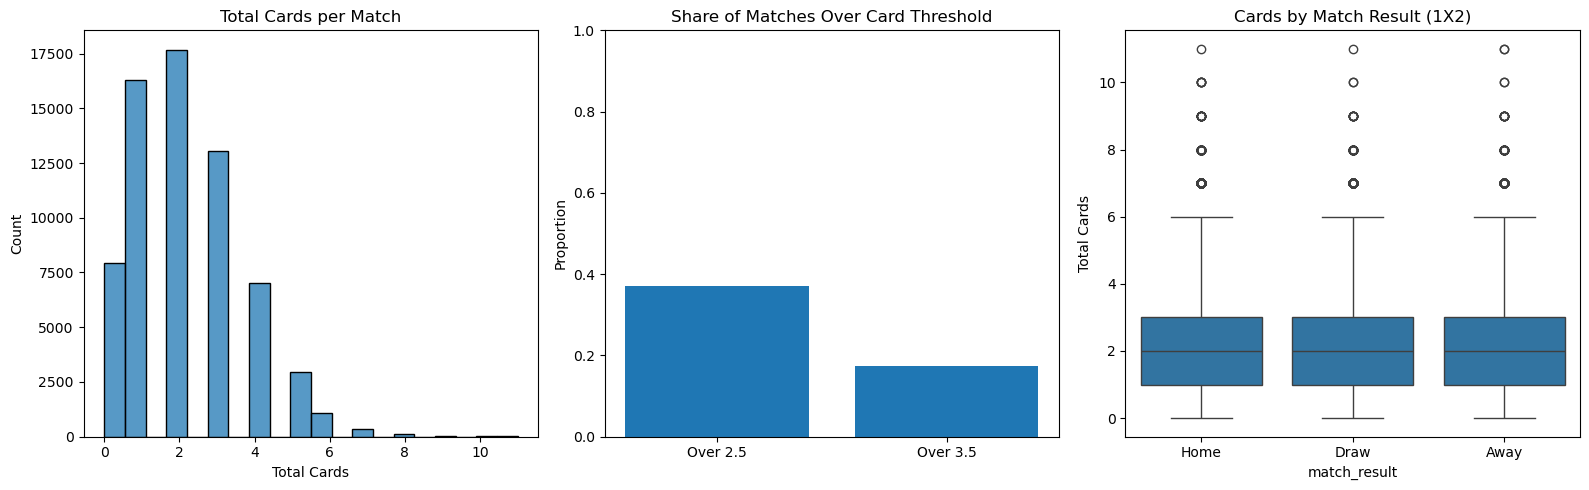

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Connect
conn = sqlite3.connect("db_sportmonks.db")

# Load card stats from the statistics table
df_cards = pd.read_sql("""
    SELECT fixture_id, type, value
    FROM statistics
    WHERE type IN ('Yellowcards', 'Redcards', 'Yellowed Cards')
""", conn)

# Convert value to numeric
df_cards["value"] = pd.to_numeric(df_cards["value"], errors="coerce")
df_cards = df_cards.dropna()

# Sum total cards per fixture
df_cards_agg = df_cards.groupby("fixture_id")["value"].sum().reset_index()
df_cards_agg.rename(columns={"value": "total_cards"}, inplace=True)

# Add labels for Over/Under thresholds
df_cards_agg["Over_2_5_cards"] = df_cards_agg["total_cards"] > 2.5
df_cards_agg["Over_3_5_cards"] = df_cards_agg["total_cards"] > 3.5

# Load match results
df_results = pd.read_sql("""
    SELECT id AS fixture_id, score_home, score_away
    FROM fixtures
    WHERE score_home IS NOT NULL AND score_away IS NOT NULL
""", conn)

df_results["match_result"] = df_results.apply(
    lambda x: "Home" if x["score_home"] > x["score_away"] else (
        "Away" if x["score_away"] > x["score_home"] else "Draw"
    ),
    axis=1
)

# Merge with card stats
df_merged = df_cards_agg.merge(df_results, on="fixture_id")

# Plot
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Distribution of total cards
sns.histplot(df_merged["total_cards"], bins=20, ax=axs[0])
axs[0].set_title("Total Cards per Match")
axs[0].set_xlabel("Total Cards")
axs[0].set_ylabel("Count")

# Share over 2.5 / 3.5
share_25 = df_merged["Over_2_5_cards"].mean()
share_35 = df_merged["Over_3_5_cards"].mean()

axs[1].bar(["Over 2.5", "Over 3.5"], [share_25, share_35])
axs[1].set_ylim(0, 1)
axs[1].set_title("Share of Matches Over Card Threshold")
axs[1].set_ylabel("Proportion")

# Cards vs 1X2 outcome
sns.boxplot(data=df_merged, x="match_result", y="total_cards", ax=axs[2])
axs[2].set_title("Cards by Match Result (1X2)")
axs[2].set_ylabel("Total Cards")

plt.tight_layout()
plt.show()

/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/4072137858.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_stats.index, x=top_stats.values, palette="Blues_r")
/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/4072137858.py:32: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


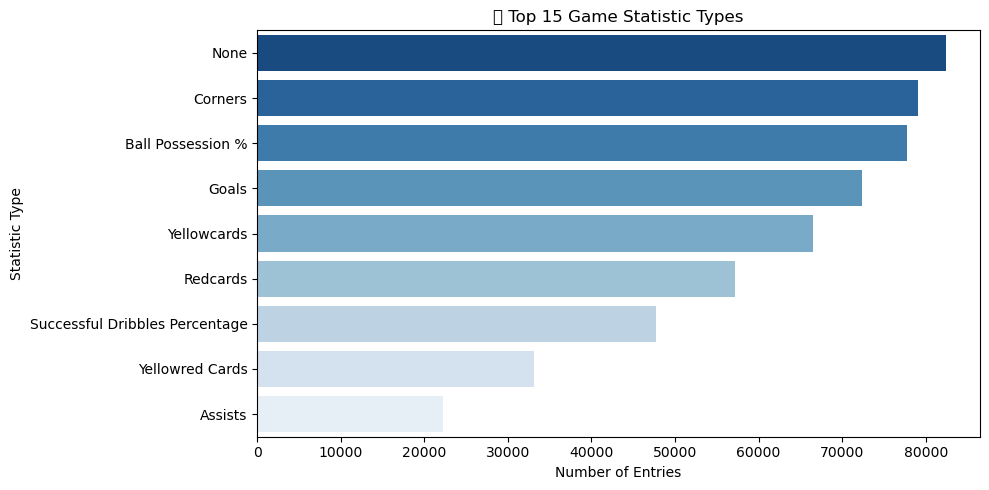

/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/4072137858.py:44: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


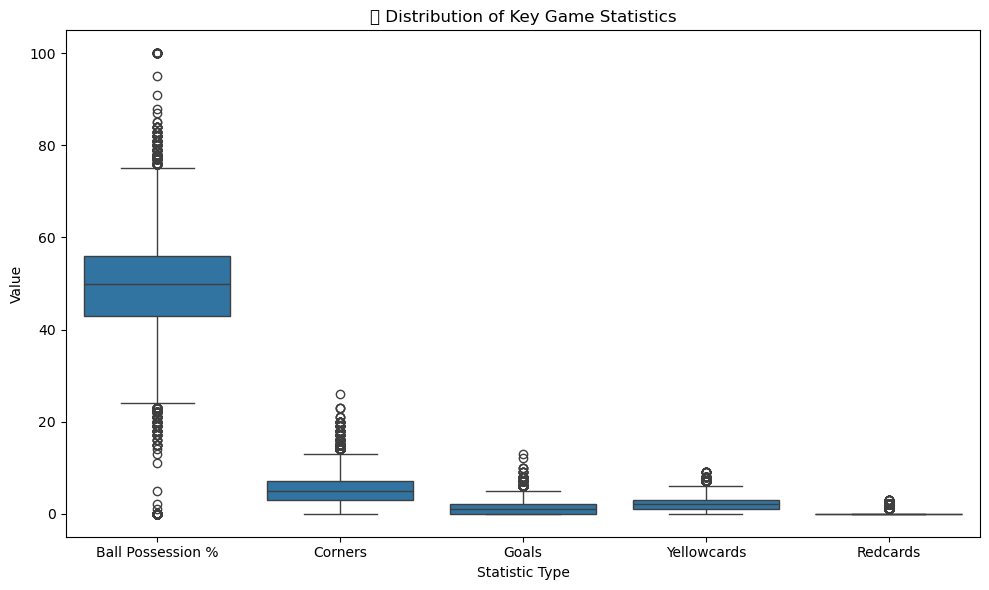

/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/4072137858.py:57: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


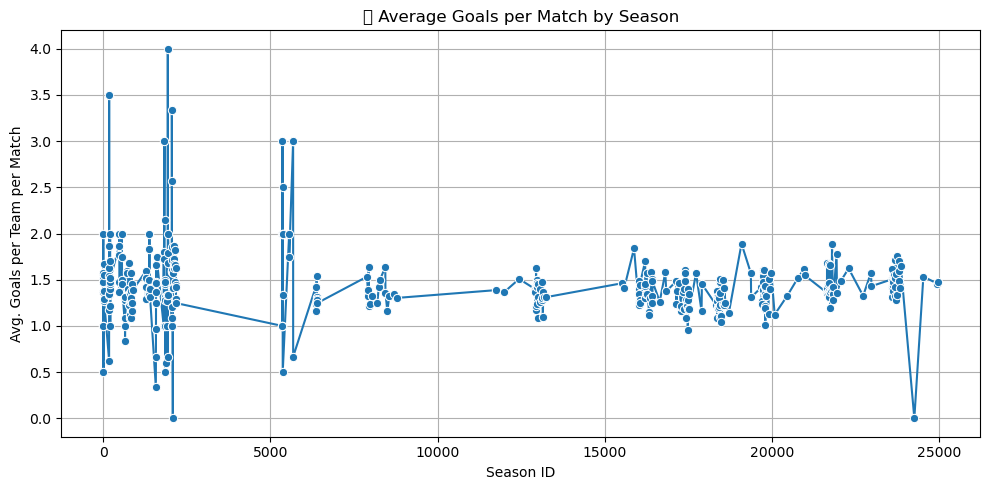

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
conn = sqlite3.connect("db_sportmonks.db")

# Load fixture and game statistics
df_stats = pd.read_sql("""
    SELECT s.fixture_id, f.season_id, f.score_home, f.score_away, f.status,
           s.team_id, s.type, s.value
    FROM statistics s
    JOIN fixtures f ON s.fixture_id = f.id
    WHERE s.type IS NOT NULL AND TRIM(s.type) != '' AND s.value IS NOT NULL
""", conn)

conn.close()

# Cast values to numeric
df_stats["value"] = pd.to_numeric(df_stats["value"], errors="coerce")
df_stats = df_stats.dropna(subset=["value"])

# Plot 1: Top 15 most common statistic types
top_stats = df_stats['type'].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(y=top_stats.index, x=top_stats.values, palette="Blues_r")
plt.title("🔢 Top 15 Game Statistic Types")
plt.xlabel("Number of Entries")
plt.ylabel("Statistic Type")
plt.tight_layout()
plt.show()

# Plot 2: Boxplot for selected types (e.g., goals, corners, possession)
selected_types = ["Goals", "Corners", "Ball Possession %", "Yellowcards", "Redcards"]
df_selected = df_stats[df_stats['type'].isin(selected_types)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_selected, x="type", y="value")
plt.title("📦 Distribution of Key Game Statistics")
plt.ylabel("Value")
plt.xlabel("Statistic Type")
plt.tight_layout()
plt.show()

# Plot 3: Season trend in average goals per match
df_goals = df_stats[df_stats["type"] == "Goals"]
avg_goals_by_season = df_goals.groupby("season_id")["value"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_goals_by_season, x="season_id", y="value", marker="o")
plt.title("📈 Average Goals per Match by Season")
plt.xlabel("Season ID")
plt.ylabel("Avg. Goals per Team per Match")
plt.grid(True)
plt.tight_layout()
plt.show()

this shows us we have a lot of statistics which is loaded under none, which could showcase, that we dont have stats from those games, or what the stats are just empty or with wrong type id.

lets have a look at the player statistics for now

In [13]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("db_sportmonks.db")

# Check how many non-null, numeric values we really have
df_raw = pd.read_sql("""
    SELECT type, value 
    FROM player_statistics 
    WHERE type IS NOT NULL AND TRIM(type) != ''
""", conn)

conn.close()

# Try converting 'value' to numeric
df_raw["value_num"] = pd.to_numeric(df_raw["value"], errors="coerce")

# Summary
print("Total entries:", len(df_raw))
print("Non-numeric values (excluded):", df_raw["value_num"].isna().sum())
print("Remaining numeric rows:", df_raw["value_num"].notna().sum())

# Top 10 types (before filtering)
print("\nTop 10 stat types by frequency:")
print(df_raw["type"].value_counts().head(10))

# Preview some valid numeric values
print("\nSample numeric entries:")
print(df_raw[df_raw["value_num"].notna()].head(5))


Total entries: 31282638
Non-numeric values (excluded): 31282638
Remaining numeric rows: 0

Top 10 stat types by frequency:
type
Minutes Played                3133666
Goals Conceded                2353714
Passes                        1656462
Accurate Passes               1640064
Rating                        1636064
Total Duels                   1544974
Duels Won                     1427523
Duels Lost                    1288758
Accurate Passes Percentage    1233884
Tackles                        933518
Name: count, dtype: int64

Sample numeric entries:
Empty DataFrame
Columns: [type, value, value_num]
Index: []


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json


In [17]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("db_sportmonks.db")
df_raw = pd.read_sql("SELECT type, value FROM player_statistics WHERE type IS NOT NULL", conn)
conn.close()


trying to filter out 0 values in the strings

In [27]:
import sqlite3
import requests
import json
from datetime import datetime

# --- Setup ---
API_TOKEN = "PgeMnb1Y71v04KzxFBpKQmm2sxsyWihIRNXSvDoYUz6ZuDOY3h1lLnmKamH1"  # Your API token
BASE_URL = "https://api.sportmonks.com/v3/football/fixtures"
TEST_FIXTURE_ID = 19135034  # ✅ Replace with any fixture ID with known stats

# --- Connect to DB ---
conn = sqlite3.connect("db_sportmonks.db")
cursor = conn.cursor()

# --- Fetch from API ---
url = f"{BASE_URL}/{TEST_FIXTURE_ID}"
params = {
    "api_token": API_TOKEN,
    "include": "statistics.type;lineups.details.type"
}
resp = requests.get(url, params=params)
resp.raise_for_status()
fixture = resp.json().get("data", {})

# --- GAME STATS ---
game_stats_inserted = 0
for stat in fixture.get("statistics", []):
    stat_type = stat.get("type", {})
    type_id = stat_type.get("id")
    type_name = stat_type.get("name")
    value = stat.get("data", {}).get("value") if isinstance(stat.get("data"), dict) else stat.get("value")

    if type_id is None or type_name is None or value is None:
        continue  # skip invalid stats

    stat_id = f"{TEST_FIXTURE_ID}_{stat.get('team_id')}_{type_id}"

    cursor.execute("""
        INSERT OR REPLACE INTO statistics (
            id, fixture_id, team_id, type, type_id, value, updated_at, raw
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        stat_id,
        TEST_FIXTURE_ID,
        stat.get("team_id") or stat.get("participant_id"),
        type_name,
        type_id,
        str(value),
        datetime.now().isoformat(),
        json.dumps(stat)
    ))
    game_stats_inserted += 1

# --- PLAYER STATS ---
player_stats_inserted = 0
for player in fixture.get("lineups", []):
    player_id = player.get("player_id")
    team_id = player.get("team_id")
    for detail in player.get("details", []):
        detail_type = detail.get("type", {})
        type_id = detail_type.get("id")
        type_name = detail_type.get("name")
        value = detail.get("value")

        if type_id is None or type_name is None or value is None:
            continue  # skip empty or malformed entries

        stat_id = f"{TEST_FIXTURE_ID}_{player_id}_{type_id}"
        cursor.execute("""
            INSERT OR REPLACE INTO player_statistics (
                id, fixture_id, player_id, team_id, type, type_id, value, updated_at, raw
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            stat_id,
            TEST_FIXTURE_ID,
            player_id,
            team_id,
            type_name,
            type_id,
            str(value),
            datetime.now().isoformat(),
            json.dumps(detail)
        ))
        player_stats_inserted += 1

conn.commit()
conn.close()

# --- Summary ---
print(f"✅ Game stats inserted: {game_stats_inserted}")
print(f"✅ Player stats inserted: {player_stats_inserted}")

✅ Game stats inserted: 12
✅ Player stats inserted: 0


In [28]:
import sqlite3
import requests
import json
from datetime import datetime
from tqdm import tqdm
import pandas as pd

# Constants
API_TOKEN = "PgeMnb1Y71v04KzxFBpKQmm2sxsyWihIRNXSvDoYUz6ZuDOY3h1lLnmKamH1"
BASE_URL = "https://api.sportmonks.com/v3/football/fixtures"
INCLUDES = "statistics.type;lineups.details.type"

# Connect to DB
conn = sqlite3.connect("db_sportmonks.db")
cursor = conn.cursor()

# Get 10 fixtures that have scores
fixture_ids = pd.read_sql("""
    SELECT id FROM fixtures 
    WHERE score_home IS NOT NULL 
    ORDER BY starting_at DESC 
    LIMIT 10
""", conn)["id"].tolist()

print(f"🎯 Testing with {len(fixture_ids)} fixtures...\n")

success, fail = 0, 0

for fixture_id in tqdm(fixture_ids, desc="📥 Fetching sample stats"):
    url = f"{BASE_URL}/{fixture_id}"
    params = {
        "api_token": API_TOKEN,
        "include": INCLUDES
    }

    try:
        res = requests.get(url, params=params)
        res.raise_for_status()
        fixture = res.json().get("data", {})

        updated = 0

        # --- Game stats ---
        for stat in fixture.get("statistics", []):
            stat_type = stat.get("type", {})
            type_id = stat_type.get("id")
            type_name = stat_type.get("name")
            if not type_id or not type_name:
                continue

            stat_id = f"{fixture_id}_{stat.get('team_id')}_{type_id}"
            cursor.execute("""
                INSERT OR REPLACE INTO statistics (
                    id, fixture_id, team_id, type, type_id, value, updated_at, raw
                ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """, (
                stat_id,
                fixture_id,
                stat.get("team_id") or stat.get("participant_id"),
                type_name,
                type_id,
                str(stat.get("data", {}).get("value", "")) if isinstance(stat.get("data"), dict) else str(stat.get("value", "")),
                datetime.now().isoformat(),
                json.dumps(stat)
            ))
            updated += 1

        # --- Player stats ---
        for player in fixture.get("lineups", []):
            player_id = player.get("player_id")
            team_id = player.get("team_id")
            for detail in player.get("details", []):
                detail_type = detail.get("type", {})
                type_id = detail_type.get("id")
                type_name = detail_type.get("name")
                if not type_id or not type_name:
                    continue

                stat_id = f"{fixture_id}_{player_id}_{type_id}"
                cursor.execute("""
                    INSERT OR REPLACE INTO player_statistics (
                        id, fixture_id, player_id, team_id, type, type_id, value, updated_at, raw
                    ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
                """, (
                    stat_id,
                    fixture_id,
                    player_id,
                    team_id,
                    type_name,
                    type_id,
                    str(detail.get("value", "")),
                    datetime.now().isoformat(),
                    json.dumps(detail)
                ))
                updated += 1

        conn.commit()
        success += 1

    except Exception as e:
        print(f"❌ Fixture {fixture_id} failed: {e}")
        fail += 1

print(f"\n✅ Sample fetch complete — Success: {success}, Failed: {fail}")
conn.close()

🎯 Testing with 10 fixtures...



📥 Fetching sample stats: 100%|██████████| 10/10 [00:02<00:00,  4.68it/s]


✅ Sample fetch complete — Success: 10, Failed: 0


In [29]:
import pandas as pd
conn = sqlite3.connect("db_sportmonks.db")

print("Sample player stats:")
display(pd.read_sql("SELECT * FROM player_statistics WHERE value IS NOT NULL LIMIT 5", conn))

print("\nSample game stats:")
display(pd.read_sql("SELECT * FROM statistics WHERE value IS NOT NULL LIMIT 5", conn))


Sample player stats:


,id,fixture_id,player_id,team_id,type,type_id,value,updated_at,raw
0,19135034_692_121,19135034,692,51,Turn Over,121,,2025-05-20T22:04:31.685121,"{""id"": 1554502338, ""fixture_id"": 19135034, ""pl..."
1,19135034_97692_56,19135034,97692,29,Fouls,56,,2025-05-20T22:10:19.878865,"{""id"": 1554563933, ""fixture_id"": 19135034, ""pl..."
2,19135034_37541456_96,19135034,37541456,51,Fouls Drawn,96,,2025-05-20T22:10:19.881349,"{""id"": 1554563935, ""fixture_id"": 19135034, ""pl..."
3,19135034_37541456_106,19135034,37541456,51,Duels Won,106,,2025-05-20T22:10:19.881356,"{""id"": 1554563936, ""fixture_id"": 19135034, ""pl..."
4,19145087_7698433_27269,19145087,7698433,618,Passes In Final Third,27269,,2025-05-20T22:10:21.521348,"{""id"": 1551849093, ""fixture_id"": 19145087, ""pl..."



Sample game stats:


,id,fixture_id,team_id,type,type_id,value,updated_at,raw
0,19129777_None_None,19129777,12038,None,None,50,2025-05-20T20:13:28.042225,"{""id"": 406530160, ""fixture_id"": 19129777, ""typ..."
1,19135032_None_None,19135032,78,None,None,1,2025-05-20T20:13:28.042296,"{""id"": 406895322, ""fixture_id"": 19135032, ""typ..."
2,19136809_None_None,19136809,593,None,None,2,2025-05-20T20:13:28.042365,"{""id"": 403723344, ""fixture_id"": 19136809, ""typ..."
3,19136810_None_None,19136810,61,None,None,1,2025-05-20T20:13:28.042430,"{""id"": 403695980, ""fixture_id"": 19136810, ""typ..."
4,19136811_None_None,19136811,1459,None,None,2,2025-05-20T20:13:28.042488,"{""id"": 403944812, ""fixture_id"": 19136811, ""typ..."


In [30]:
import sqlite3
import pandas as pd
import json

# Connect and fetch a few rows
conn = sqlite3.connect("db_sportmonks.db")
df_sample = pd.read_sql("""
    SELECT type, value, raw
    FROM player_statistics
    WHERE type IS NOT NULL
    LIMIT 10
""", conn)
conn.close()

# Try parsing and showing raw content
def show_raw_info(row):
    try:
        raw = json.loads(row["raw"])
        return raw.get("data", {}), raw.get("type", {}), raw.get("value", "—")
    except Exception:
        return "Parse error", {}, "—"

df_sample[["data_from_raw", "type_from_raw", "value_field"]] = df_sample.apply(show_raw_info, axis=1, result_type="expand")

# Show it
display(df_sample)


,type,value,raw,data_from_raw,type_from_raw,value_field
0,Turn Over,,"{""id"": 1554502338, ""fixture_id"": 19135034, ""pl...",{'value': 1},"{'id': 121, 'name': 'Turn Over', 'code': 'turn...",—
1,Fouls,,"{""id"": 1554563933, ""fixture_id"": 19135034, ""pl...",{'value': 1},"{'id': 56, 'name': 'Fouls', 'code': 'fouls', '...",—
2,Fouls Drawn,,"{""id"": 1554563935, ""fixture_id"": 19135034, ""pl...",{'value': 1},"{'id': 96, 'name': 'Fouls Drawn', 'code': 'fou...",—
3,Duels Won,,"{""id"": 1554563936, ""fixture_id"": 19135034, ""pl...",{'value': 1},"{'id': 106, 'name': 'Duels Won', 'code': 'duel...",—
4,Passes In Final Third,,"{""id"": 1551849093, ""fixture_id"": 19145087, ""pl...",{'value': 2},"{'id': 27269, 'name': 'Passes In Final Third',...",—
5,Ball Recovery,,"{""id"": 1551849094, ""fixture_id"": 19145087, ""pl...",{'value': 1},"{'id': 27271, 'name': 'Ball Recovery', 'code':...",—
6,Offsides,,"{""id"": 1551862329, ""fixture_id"": 19145087, ""pl...",{'value': 2},"{'id': 51, 'name': 'Offsides', 'code': 'offsid...",—
7,Accurate Crosses,,"{""id"": 1551854582, ""fixture_id"": 19145087, ""pl...",{'value': 2},"{'id': 99, 'name': 'Accurate Crosses', 'code':...",—
8,Key Passes,,"{""id"": 1551860382, ""fixture_id"": 19145087, ""pl...",{'value': 3},"{'id': 117, 'name': 'Key Passes', 'code': 'key...",—
9,Dribble Attempts,,"{""id"": 1551852267, ""fixture_id"": 19145087, ""pl...",{'value': 2},"{'id': 108, 'name': 'Dribble Attempts', 'code'...",—


In [31]:
import sqlite3
import pandas as pd
import json
from tqdm import tqdm
from datetime import datetime

# Connect to the DB
conn = sqlite3.connect("db_sportmonks.db")
cursor = conn.cursor()

# Fetch entries where value is NULL or empty
df_missing = pd.read_sql("""
    SELECT id, raw 
    FROM player_statistics 
    WHERE TRIM(value) IS NULL OR TRIM(value) = ''
""", conn)

print(f"🔍 Stats to update: {len(df_missing):,}")

# Parse JSON and update value
updates = 0
for idx, row in tqdm(df_missing.iterrows(), total=len(df_missing)):
    try:
        raw_json = json.loads(row['raw'])
        if isinstance(raw_json, dict):
            val = raw_json.get("data", {}).get("value", None)
            if val is not None:
                cursor.execute("""
                    UPDATE player_statistics
                    SET value = ?, updated_at = ?
                    WHERE id = ?
                """, (
                    str(val),
                    datetime.now().isoformat(),
                    row["id"]
                ))
                updates += 1
    except Exception as e:
        continue

conn.commit()
conn.close()

print(f"✅ Updated {updates:,} player_statistics rows from raw JSON.")


🔍 Stats to update: 31,282,644


100%|██████████| 31282644/31282644 [08:50<00:00, 58999.10it/s]


✅ Updated 31,282,644 player_statistics rows from raw JSON.


we'll verify we have everything now for the last time.

In [32]:
import sqlite3
import pandas as pd

# Connect to database
conn = sqlite3.connect("db_sportmonks.db")

# Load a sample of player_statistics
df_sample = pd.read_sql("""
    SELECT fixture_id, player_id, team_id, type, type_id, value
    FROM player_statistics
    WHERE type IS NOT NULL AND TRIM(value) != ''
    LIMIT 100
""", conn)

# Try converting 'value' to numeric
df_sample["value_num"] = pd.to_numeric(df_sample["value"], errors="coerce")

# Show how many are successfully parsed
valid_count = df_sample["value_num"].notna().sum()
print(f"✅ Parsed numeric player statistics: {valid_count} / {len(df_sample)}")

# Preview the parsed values
print("\n🔍 Sample parsed entries:")
print(df_sample[df_sample["value_num"].notna()].head(10))

conn.close()


✅ Parsed numeric player statistics: 99 / 100

🔍 Sample parsed entries:
   fixture_id  player_id  team_id                   type  type_id value  \
0    19135034        692       51              Turn Over      121     1   
1    19135034      97692       29                  Fouls       56     1   
2    19135034   37541456       51            Fouls Drawn       96     1   
3    19135034   37541456       51              Duels Won      106     1   
4    19145087    7698433      618  Passes In Final Third    27269     2   
5    19145087    7698433      618          Ball Recovery    27271     1   
6    19145087    7698433      618               Offsides       51     2   
7    19145087    7698433      618       Accurate Crosses       99     2   
8    19145087    7698433      618             Key Passes      117     3   
9    19145087    7698433      618       Dribble Attempts      108     2   

   value_num  
0        1.0  
1        1.0  
2        1.0  
3        1.0  
4        2.0  
5        1.0 

✅ Parsed numeric player statistics: 499,368


/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/3350005878.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, y="type", order=top_types, palette="mako")


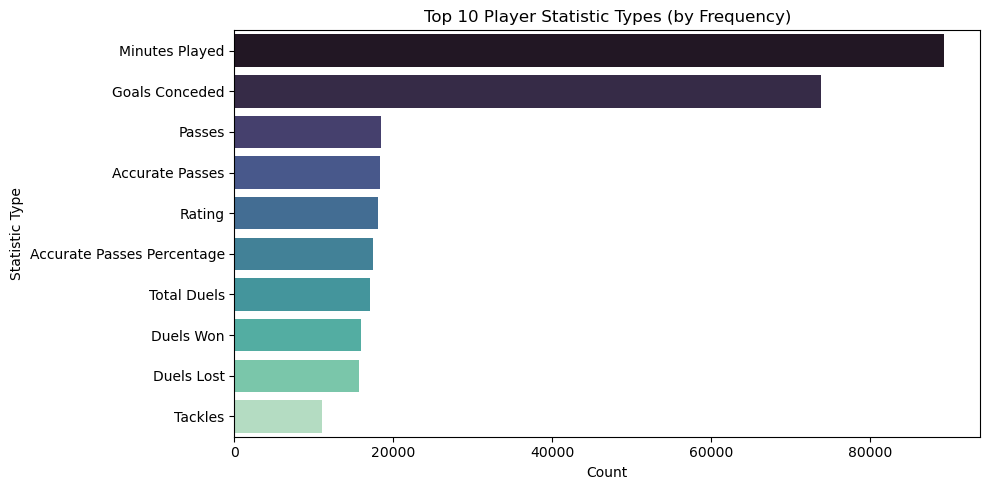

/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/3350005878.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x="type", y="value_num", order=top_types, palette="Set2")


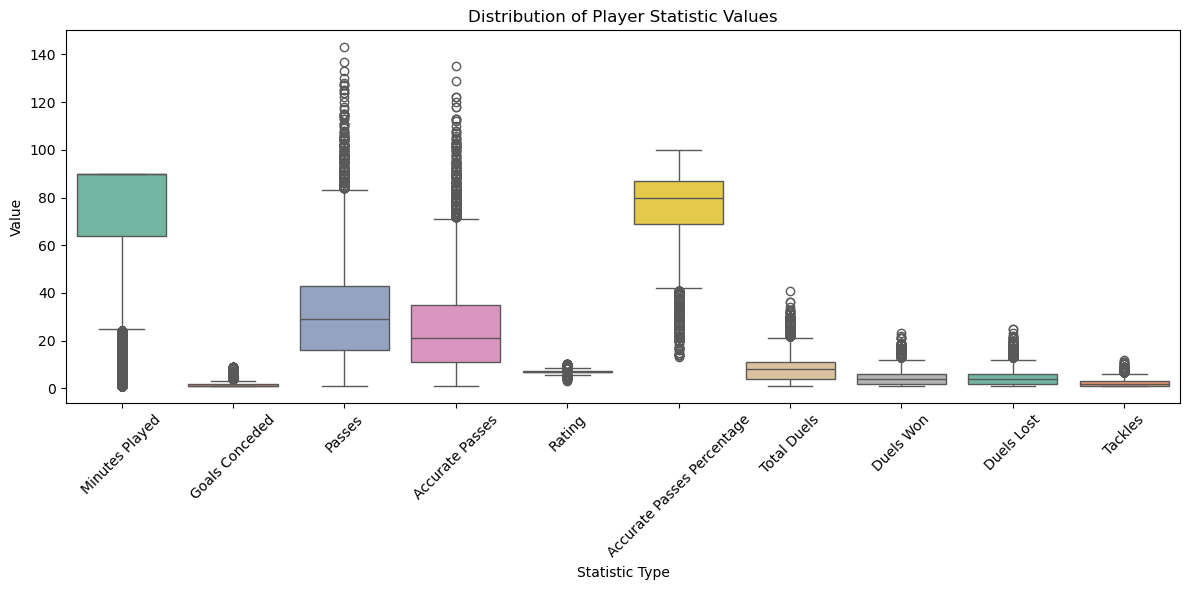

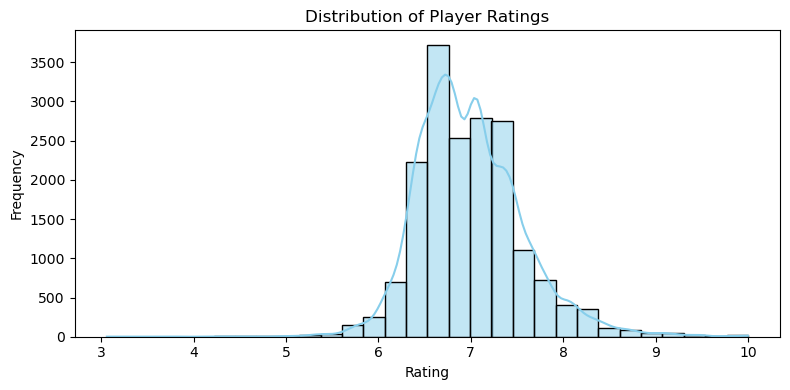

In [33]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Connect to DB
conn = sqlite3.connect("db_sportmonks.db")

# Load player statistics with non-null type/value
df_raw = pd.read_sql("""
    SELECT fixture_id, player_id, team_id, type, value
    FROM player_statistics
    WHERE type IS NOT NULL AND value IS NOT NULL
    LIMIT 500000
""", conn)
conn.close()

# Convert JSON or raw string to numeric
def parse_numeric(val):
    try:
        parsed = json.loads(val)
        if isinstance(parsed, dict) and "value" in parsed:
            return float(parsed["value"])
        return float(val)
    except:
        return None

df_raw["value_num"] = df_raw["value"].apply(parse_numeric)

# Filter numeric values
df_numeric = df_raw[df_raw["value_num"].notna()]
print(f"✅ Parsed numeric player statistics: {len(df_numeric):,}")

# Get top 10 stat types
top_types = df_numeric["type"].value_counts().head(10).index.tolist()
df_top = df_numeric[df_numeric["type"].isin(top_types)]

# Plot 1: Count of top stat types
plt.figure(figsize=(10, 5))
sns.countplot(data=df_top, y="type", order=top_types, palette="mako")
plt.title("Top 10 Player Statistic Types (by Frequency)")
plt.xlabel("Count")
plt.ylabel("Statistic Type")
plt.tight_layout()
plt.show()

# Plot 2: Boxplot distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x="type", y="value_num", order=top_types, palette="Set2")
plt.title("Distribution of Player Statistic Values")
plt.xlabel("Statistic Type")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: Histogram of "Rating"
if "Rating" in top_types:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_top[df_top["type"] == "Rating"]["value_num"], bins=30, kde=True, color="skyblue")
    plt.title("Distribution of Player Ratings")
    plt.xlabel("Rating")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/3520262197.py:48: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


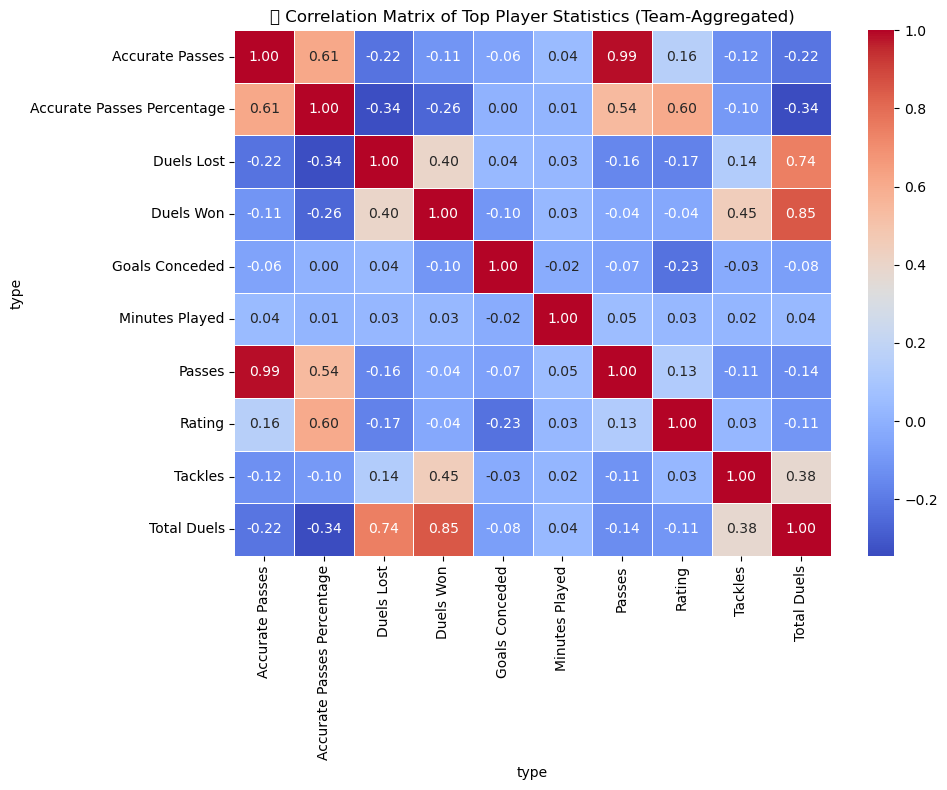

In [34]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Connect to DB
conn = sqlite3.connect("db_sportmonks.db")

# Load raw player stats
df_raw = pd.read_sql("""
    SELECT fixture_id, team_id, type, value
    FROM player_statistics
    WHERE type IS NOT NULL AND value IS NOT NULL
""", conn)
conn.close()

# Parse numeric values
def parse_numeric(val):
    try:
        parsed = json.loads(val)
        if isinstance(parsed, dict) and "value" in parsed:
            return float(parsed["value"])
        return float(val)
    except:
        return None

df_raw["value_num"] = df_raw["value"].apply(parse_numeric)
df_numeric = df_raw[df_raw["value_num"].notna()]

# Pick top 10 most common stat types
top_types = df_numeric["type"].value_counts().head(10).index.tolist()
df_top = df_numeric[df_numeric["type"].isin(top_types)]

# Aggregate per fixture_id and team_id
df_agg = df_top.groupby(["fixture_id", "team_id", "type"])["value_num"].sum().reset_index()

# Pivot to wide format
pivot_df = df_agg.pivot_table(index=["fixture_id", "team_id"], columns="type", values="value_num").dropna()

# Correlation matrix
corr_matrix = pivot_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("🔁 Correlation Matrix of Top Player Statistics (Team-Aggregated)")
plt.tight_layout()
plt.show()


ideally we should now choose the features we want to work with after displaying the data in the EDA before the selection.

this also give us the opportunity to later on apply models to player props betting.

In [35]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the DB
conn = sqlite3.connect("db_sportmonks.db")

# Load core data tables
df_fixtures = pd.read_sql("""
    SELECT id AS fixture_id, league_id, season_id, home_team_id, away_team_id, 
           score_home, score_away, starting_at
    FROM fixtures
    WHERE score_home IS NOT NULL AND score_away IS NOT NULL
""", conn)

df_stats = pd.read_sql("""
    SELECT fixture_id, team_id, type, value
    FROM statistics
    WHERE type IS NOT NULL AND TRIM(type) != ''
""", conn)

df_player = pd.read_sql("""
    SELECT fixture_id, player_id, team_id, type, value
    FROM player_statistics
    WHERE type IS NOT NULL AND TRIM(type) != ''
""", conn)

conn.close()

print("✅ Fixtures:", df_fixtures.shape)
print("✅ Game Stats:", df_stats.shape)
print("✅ Player Stats:", df_player.shape)


✅ Fixtures: (154495, 8)
✅ Game Stats: (538336, 4)
✅ Player Stats: (31282644, 5)


In [36]:
# Convert 'value' column in both stats tables to numeric where possible
df_stats["value_num"] = pd.to_numeric(df_stats["value"], errors="coerce")
df_player["value_num"] = pd.to_numeric(df_player["value"], errors="coerce")

# Drop rows with invalid/missing numeric values
df_stats = df_stats.dropna(subset=["value_num"])
df_player = df_player.dropna(subset=["value_num"])

print("🔢 Cleaned Game Stats:", df_stats.shape)
print("🔢 Cleaned Player Stats:", df_player.shape)


🔢 Cleaned Game Stats: (538318, 5)
🔢 Cleaned Player Stats: (31179693, 6)


/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/1773668686.py:11: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


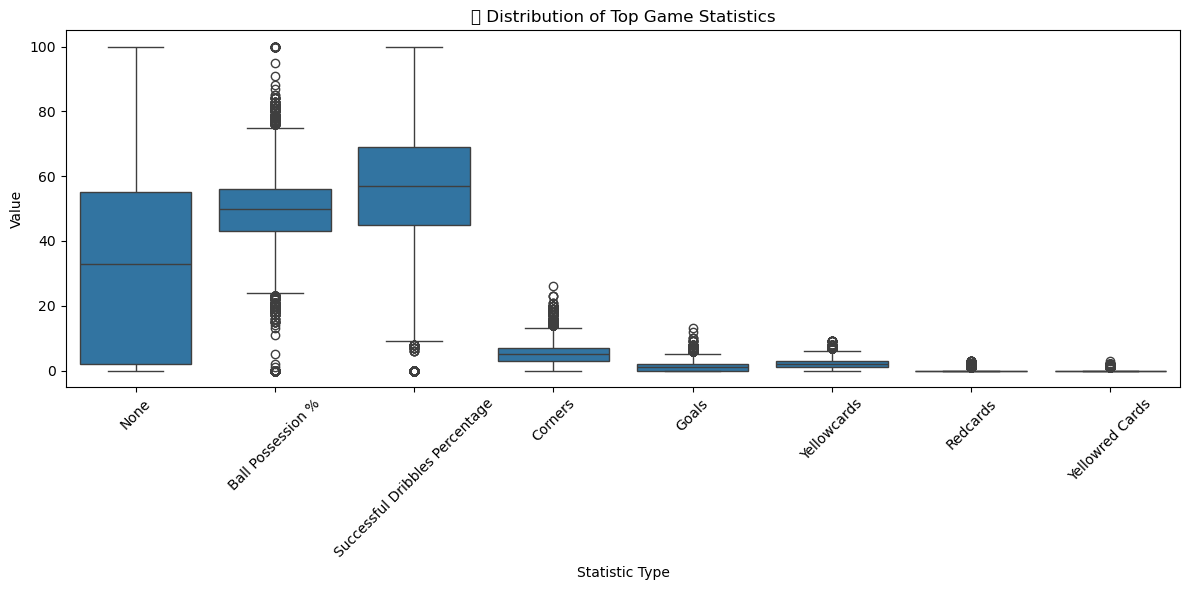

In [37]:
# Visualize top game-level stats
top_types = df_stats["type"].value_counts().head(8).index.tolist()
df_top_stats = df_stats[df_stats["type"].isin(top_types)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_stats, x="type", y="value_num")
plt.title("📊 Distribution of Top Game Statistics")
plt.ylabel("Value")
plt.xlabel("Statistic Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


analyzing player stats a bit further 

/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/1410690598.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, y="type", order=top_types, palette="rocket")


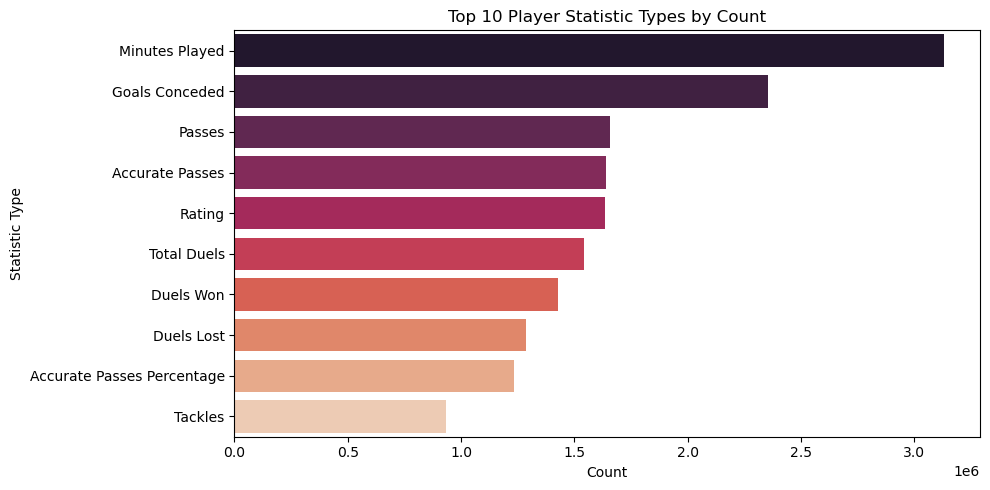

/var/folders/nl/dl4x3l3x1dd8twj43d1ddkx80000gn/T/ipykernel_7089/1410690598.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x="type", y="value_num", order=top_types, palette="coolwarm")


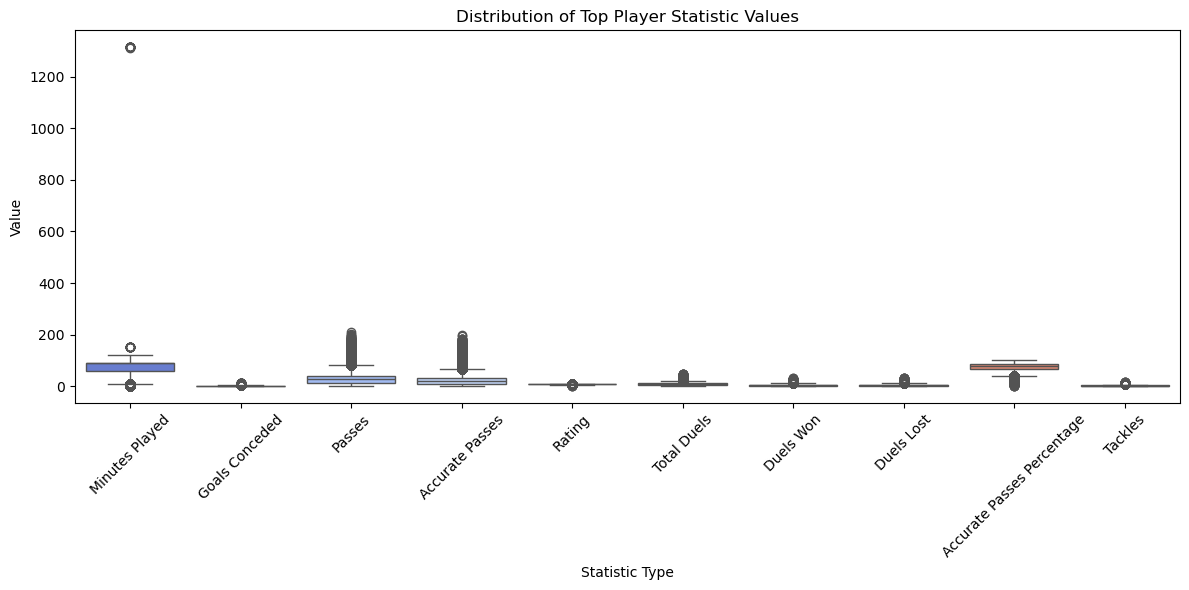

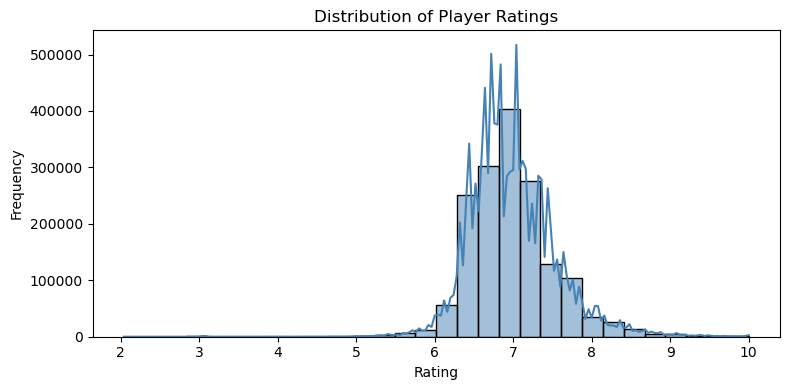

In [38]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the database
conn = sqlite3.connect("db_sportmonks.db")
df_player = pd.read_sql("""
    SELECT fixture_id, player_id, team_id, type, value
    FROM player_statistics
    WHERE type IS NOT NULL AND TRIM(type) != ''
""", conn)
conn.close()

# Convert 'value' column to numeric
df_player["value_num"] = pd.to_numeric(df_player["value"], errors="coerce")
df_player = df_player.dropna(subset=["value_num"])

# Get top 10 most frequent stat types
top_types = df_player["type"].value_counts().head(10).index.tolist()
df_top = df_player[df_player["type"].isin(top_types)]

# Plot 1: Count of top stat types
plt.figure(figsize=(10, 5))
sns.countplot(data=df_top, y="type", order=top_types, palette="rocket")
plt.title("Top 10 Player Statistic Types by Count")
plt.xlabel("Count")
plt.ylabel("Statistic Type")
plt.tight_layout()
plt.show()

# Plot 2: Distribution of values for top stat types
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x="type", y="value_num", order=top_types, palette="coolwarm")
plt.title("Distribution of Top Player Statistic Values")
plt.xlabel("Statistic Type")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: Histogram for Rating if available
if "Rating" in top_types:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_top[df_top["type"] == "Rating"]["value_num"], bins=30, kde=True, color="steelblue")
    plt.title("Distribution of Player Ratings")
    plt.xlabel("Rating")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


Steps from here.



Choose the features --> which will be the statistics

we'll then load all the core data again for good measures
--> it consists of fixtures with scores, the statistics (pivoted into features), player statistics (aggregated per team per match, should match) and odds will we either joined now, otherwise they will me joined later

we then are going to create the target columns which are:
1X2 label from the scores (home w if > away score vice versa)
O/U 2,5 and 3,5 goals 
O/U 2,5 and 3,5 cards
(maybe) BTTS - both teams to score
(maybe) player props - passes, tackles etc


we then merge match statistics per fixture/team as features
we aggregate the player stats per fixture/team - sum or mean
then we merge it onto the fixture row


it should be so we get one row per match
--> features from match statistics and aggregated player statistics
labels from scores and cards
Odds (which will be used to calculate the ROI later on)


we'll create the df now, which we will use as training, and then we will train 4 diffrent traditional model, logistic regression, xgboost, graident boosting and random forest

In [39]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("db_sportmonks.db")

# 1. Load Allsvenskan fixtures with scores
fixtures = pd.read_sql("""
    SELECT f.id AS fixture_id, f.home_team_id, f.away_team_id, f.score_home, f.score_away
    FROM fixtures f
    JOIN leagues l ON f.league_id = l.id
    WHERE l.name = 'Allsvenskan' AND f.score_home IS NOT NULL AND f.score_away IS NOT NULL
""", conn)

# 2. Match statistics
match_stats = pd.read_sql("""
    SELECT fixture_id, team_id, type, value
    FROM statistics
    WHERE fixture_id IN (SELECT id FROM fixtures WHERE league_id IN 
        (SELECT id FROM leagues WHERE name = 'Allsvenskan'))
      AND type IS NOT NULL AND value IS NOT NULL
""", conn)
match_stats["value"] = pd.to_numeric(match_stats["value"], errors="coerce")
match_stats_pivot = match_stats.pivot_table(index=["fixture_id", "team_id"], 
                                            columns="type", values="value", aggfunc="mean").reset_index()

# 3. Player statistics
player_stats = pd.read_sql("""
    SELECT fixture_id, team_id, type, value
    FROM player_statistics
    WHERE fixture_id IN (SELECT id FROM fixtures WHERE league_id IN 
        (SELECT id FROM leagues WHERE name = 'Allsvenskan'))
      AND type IS NOT NULL AND value IS NOT NULL
""", conn)
player_stats["value"] = pd.to_numeric(player_stats["value"], errors="coerce")
player_stats_agg = player_stats.groupby(["fixture_id", "team_id", "type"]).agg({"value": "sum"}).reset_index()
player_stats_pivot = player_stats_agg.pivot_table(index=["fixture_id", "team_id"], 
                                                  columns="type", values="value", aggfunc="sum").reset_index()

# 4. Merge game and player stats
features_combined = pd.merge(match_stats_pivot, player_stats_pivot, 
                             on=["fixture_id", "team_id"], how="outer", suffixes=('_match', '_player'))

# 5. Merge with fixtures
home = features_combined.rename(columns=lambda x: f"{x}_home" if x not in ['fixture_id', 'team_id'] else x)
home = pd.merge(fixtures, home, left_on=["fixture_id", "home_team_id"], right_on=["fixture_id", "team_id"], how="left")

away = features_combined.rename(columns=lambda x: f"{x}_away" if x not in ['fixture_id', 'team_id'] else x)
final_df = pd.merge(home, away, left_on=["fixture_id", "away_team_id"], right_on=["fixture_id", "team_id"], how="left")

# 6. Create targets
final_df["target_result"] = final_df.apply(lambda row: "1" if row["score_home"] > row["score_away"]
                                           else "2" if row["score_home"] < row["score_away"]
                                           else "X", axis=1)
final_df["total_goals"] = final_df["score_home"] + final_df["score_away"]
final_df["target_ou_2_5_goals"] = (final_df["total_goals"] > 2.5).astype(int)
final_df["target_ou_3_5_goals"] = (final_df["total_goals"] > 3.5).astype(int)

# Optional: card total from stats if available
final_df["total_cards"] = 0  # Fill later
final_df["target_ou_2_5_cards"] = 0
final_df["target_ou_3_5_cards"] = 0

conn.close()

# Preview
print(f"✅ Allsvenskan dataset created with {len(final_df)} rows")
final_df.head()


✅ Allsvenskan dataset created with 4710 rows


,fixture_id,home_team_id,away_team_id,score_home,score_away,team_id_x,Assists_match_home,Ball Possession %_home,Corners_home,Goals_match_home,...,Touches_away,Yellowcards_player_away,Yellowred Cards_player_away,target_result,total_goals,target_ou_2_5_goals,target_ou_3_5_goals,total_cards,target_ou_2_5_cards,target_ou_3_5_cards
0,234348,80,3603,1,2,80.0,NaN,44.0,NaN,NaN,...,NaN,NaN,NaN,2,3,1,0,0,0,0
1,234349,432,2535,0,1,432.0,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,2,1,0,0,0,0,0
2,234350,2825,1339,1,0,NaN,NaN,NaN,NaN,NaN,...,NaN,2.0,NaN,1,1,0,0,0,0,0
3,234351,720,2353,1,2,720.0,NaN,61.0,NaN,NaN,...,NaN,NaN,NaN,2,3,1,0,0,0,0
4,234352,9179,1405,0,0,9179.0,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,X,0,0,0,0,0,0


In [186]:
import sqlite3
import pandas as pd

# Connect to SQLite DB
conn = sqlite3.connect("db_sportmonks.db")

# Step 1: Get completed Allsvenskan fixtures with scores
fixtures = pd.read_sql("""
    SELECT f.id AS fixture_id, f.home_team_id, f.away_team_id, f.score_home, f.score_away, f.starting_at
    FROM fixtures f
    JOIN leagues l ON f.league_id = l.id
    WHERE l.name = 'Allsvenskan'
      AND f.score_home IS NOT NULL AND f.score_away IS NOT NULL
""", conn)

# Step 2: Get team statistics
match_stats = pd.read_sql("""
    SELECT fixture_id, team_id, type, value
    FROM statistics
    WHERE fixture_id IN (
        SELECT id FROM fixtures WHERE league_id IN (
            SELECT id FROM leagues WHERE name = 'Allsvenskan'
        )
    ) AND type IS NOT NULL AND value IS NOT NULL
""", conn)
match_stats["value"] = pd.to_numeric(match_stats["value"], errors="coerce")
match_stats_pivot = match_stats.pivot_table(
    index=["fixture_id", "team_id"], columns="type", values="value", aggfunc="mean"
).reset_index()

# Step 3: Get player statistics
player_stats = pd.read_sql("""
    SELECT fixture_id, team_id, type, value
    FROM player_statistics
    WHERE fixture_id IN (
        SELECT id FROM fixtures WHERE league_id IN (
            SELECT id FROM leagues WHERE name = 'Allsvenskan'
        )
    ) AND type IS NOT NULL AND value IS NOT NULL
""", conn)
player_stats["value"] = pd.to_numeric(player_stats["value"], errors="coerce")
player_stats_agg = player_stats.groupby(["fixture_id", "team_id", "type"]).agg({"value": "sum"}).reset_index()
player_stats_pivot = player_stats_agg.pivot_table(
    index=["fixture_id", "team_id"], columns="type", values="value", aggfunc="sum"
).reset_index()

# Step 4: Combine team and player stats
features_combined = pd.merge(
    match_stats_pivot, player_stats_pivot,
    on=["fixture_id", "team_id"], how="outer",
    suffixes=('_match', '_player')
)

# Step 5: Merge home and away stats into one row per match
home_stats = features_combined.rename(columns=lambda col: f"{col}_home" if col not in ["fixture_id", "team_id"] else col)
away_stats = features_combined.rename(columns=lambda col: f"{col}_away" if col not in ["fixture_id", "team_id"] else col)

final_df = pd.merge(fixtures, home_stats, left_on=["fixture_id", "home_team_id"], right_on=["fixture_id", "team_id"], how="left")
final_df = pd.merge(final_df, away_stats, left_on=["fixture_id", "away_team_id"], right_on=["fixture_id", "team_id"], how="left")

# Step 6: Add targets
final_df["target_1x2"] = final_df.apply(lambda row: 0 if row["score_home"] > row["score_away"]
                                        else 1 if row["score_home"] == row["score_away"]
                                        else 2, axis=1)
final_df["total_goals"] = final_df["score_home"] + final_df["score_away"]
final_df["target_ou_2_5_goals"] = (final_df["total_goals"] > 2.5).astype(int)
final_df["target_ou_3_5_goals"] = (final_df["total_goals"] > 3.5).astype(int)

# Optionally: Calculate total cards if stored in stats
card_cols = ["Yellowcards_match_home", "Yellowcards_match_away"]
if all(col in final_df.columns for col in card_cols):
    final_df["total_cards"] = final_df["Yellowcards_match_home"].fillna(0) + final_df["Yellowcards_match_away"].fillna(0)
else:
    final_df["total_cards"] = 0

final_df["target_ou_2_5_cards"] = (final_df["total_cards"] > 2.5).astype(int)
final_df["target_ou_3_5_cards"] = (final_df["total_cards"] > 3.5).astype(int)

# Step 7: Add 1X2 odds
odds = pd.read_sql("""
    SELECT fixture_id, odds_label, odds_value
    FROM fixture_odds
    WHERE market_name = 'Fulltime Result'
""", conn)

# Pivot odds
odds_pivot = odds.pivot_table(
    index="fixture_id",
    columns="odds_label",
    values="odds_value",
    aggfunc="first"
).rename(columns={"1": "odds_home", "X": "odds_draw", "2": "odds_away"}).reset_index()

# Merge odds into final_df
final_df = final_df.merge(odds_pivot, on="fixture_id", how="left")

# Close DB connection
conn.close()

# Display output
print(f"✅ Final dataset: {len(final_df)} matches loaded")
display_cols = ["fixture_id", "score_home", "score_away", "target_1x2",
                "target_ou_2_5_goals", "target_ou_3_5_goals",
                "odds_home", "odds_draw", "odds_away"]
print(final_df[display_cols].head())

✅ Final dataset: 4710 matches loaded
   fixture_id  score_home  score_away  target_1x2  target_ou_2_5_goals  \
0      234348           1           2           2                    1   
1      234349           0           1           2                    0   
2      234350           1           0           0                    0   
3      234351           1           2           2                    1   
4      234352           0           0           1                    0   

   target_ou_3_5_goals odds_home odds_draw odds_away  
0                    0       NaN       NaN       NaN  
1                    0      3.25      3.45      2.15  
2                    0      1.43      4.25      7.75  
3                    0       2.9      3.25       2.4  
4                    0       2.8      3.15      2.55  


In [ ]:
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import numpy as np

# === Step 1: Setup
TARGETS = {
    "1x2": "target_1x2",
    "ou_2_5_goals": "target_ou_2_5_goals",
    "ou_3_5_goals": "target_ou_3_5_goals",
    "ou_2_5_cards": "target_ou_2_5_cards",
    "ou_3_5_cards": "target_ou_3_5_cards"
}

MODELS = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
    "xgboost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Columns we know leak target info
leakage_cols = list(TARGETS.values()) + [
    "score_home", "score_away", "total_goals", "total_cards"
]

# Build feature matrix (drop odds and leakage)
X_all = final_df.drop(columns=[col for col in final_df.columns if col in leakage_cols or col.startswith("odds")])
X_all = X_all.select_dtypes(include=[np.number]).fillna(0)

# Create model save directory
os.makedirs("saved_models", exist_ok=True)

# === Step 2: Train + Save
for name, target_col in TARGETS.items():
    if target_col not in final_df.columns:
        print(f"⚠️ Skipping {name} — column missing")
        continue

    y = final_df[target_col].dropna()
    if y.nunique() < 2:
        print(f"⚠️ Skipping {name} — only one class found")
        continue

    X = X_all.loc[y.index]
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in MODELS.items():
        print(f"\n🎯 Training {model_name} on {name}...")
        try:
            if model_name == "xgboost":
                model = xgb.XGBClassifier(
                    use_label_encoder=False,
                    eval_metric="mlogloss" if y.nunique() > 2 else "logloss",
                    objective="multi:softmax" if y.nunique() > 2 else "binary:logistic",
                    num_class=y.nunique() if y.nunique() > 2 else None,
                    random_state=42
                )

            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            print(classification_report(y_test, y_pred))

            bundle = {
                "model": model,
                "scaler": scaler,
                "features": list(X.columns)
            }
            joblib.dump(bundle, f"saved_models/{name}_{model_name}.pkl")
        except Exception as e:
            print(f"❌ {model_name} failed on {name}: {e}")


🎯 Training logistic_regression on 1x2...
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       422
           1       0.96      0.75      0.84       236
           2       0.98      0.78      0.87       284

    accuracy                           0.87       942
   macro avg       0.91      0.84      0.86       942
weighted avg       0.89      0.87      0.87       942


🎯 Training random_forest on 1x2...
              precision    recall  f1-score   support

           0       0.85      0.92      0.89       422
           1       0.82      0.75      0.78       236
           2       0.86      0.82      0.84       284

    accuracy                           0.85       942
   macro avg       0.84      0.83      0.84       942
weighted avg       0.85      0.85      0.85       942


🎯 Training gradient_boosting on 1x2...
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       422
           

In [188]:
import sqlite3
import pandas as pd

# Connect to your database
conn = sqlite3.connect("db_sportmonks.db")

# Step 1: Load upcoming fixtures with future dates (no scores yet)
fixtures = pd.read_sql("""
    SELECT f.id AS fixture_id, f.home_team_id, f.away_team_id, f.starting_at
    FROM fixtures f
    JOIN leagues l ON f.league_id = l.id
    WHERE f.score_home IS NULL AND f.score_away IS NULL
""", conn)

# Step 2: Load stats
stats = pd.read_sql("""
    SELECT fixture_id, team_id, type, value
    FROM statistics
    WHERE fixture_id IN (SELECT id FROM fixtures WHERE score_home IS NULL AND score_away IS NULL)
""", conn)
stats["value"] = pd.to_numeric(stats["value"], errors="coerce")
stats_pivot = stats.pivot_table(index=["fixture_id", "team_id"], columns="type", values="value", aggfunc="mean").reset_index()

# Step 3: Load player stats
player_stats = pd.read_sql("""
    SELECT fixture_id, team_id, type, value
    FROM player_statistics
    WHERE fixture_id IN (SELECT id FROM fixtures WHERE score_home IS NULL AND score_away IS NULL)
""", conn)
player_stats["value"] = pd.to_numeric(player_stats["value"], errors="coerce")
player_stats_agg = player_stats.groupby(["fixture_id", "team_id", "type"]).agg({"value": "sum"}).reset_index()
player_stats_pivot = player_stats_agg.pivot_table(index=["fixture_id", "team_id"], columns="type", values="value", aggfunc="sum").reset_index()

# Step 4: Combine
combined = pd.merge(stats_pivot, player_stats_pivot, on=["fixture_id", "team_id"], how="outer", suffixes=('_match', '_player'))

# Step 5: Merge home/away
home = combined.rename(columns=lambda c: f"{c}_home" if c not in ["fixture_id", "team_id"] else c)
away = combined.rename(columns=lambda c: f"{c}_away" if c not in ["fixture_id", "team_id"] else c)

df = pd.merge(fixtures, home, left_on=["fixture_id", "home_team_id"], right_on=["fixture_id", "team_id"], how="left")
final_df_upcoming = pd.merge(df, away, left_on=["fixture_id", "away_team_id"], right_on=["fixture_id", "team_id"], how="left")

conn.close()
print(f"✅ final_df_upcoming ready: {len(final_df_upcoming)} fixtures")


✅ final_df_upcoming ready: 1057 fixtures


In [189]:
# Load any model bundle to get the expected features
import joblib

sample_bundle = joblib.load("saved_models/1x2_logistic_regression.pkl")
expected_features = sample_bundle["features"]

# Add missing columns with 0.0
for col in expected_features:
    if col not in final_df_upcoming.columns:
        final_df_upcoming[col] = 0.0

# Ensure correct column order
final_df_upcoming = final_df_upcoming[expected_features]


In [193]:
# Cast team ID columns to numeric type
final_df_upcoming["home_team_id"] = pd.to_numeric(final_df_upcoming["home_team_id"], errors="coerce")
final_df_upcoming["away_team_id"] = pd.to_numeric(final_df_upcoming["away_team_id"], errors="coerce")

In [192]:
import os
import joblib
import pandas as pd
import numpy as np

MODEL_DIR = "saved_models"

# Safe init
meta_cols = ["fixture_id"]
if "starting_at" in final_df_upcoming.columns:
    meta_cols.append("starting_at")
preds_df = final_df_upcoming[meta_cols].copy()

for filename in os.listdir(MODEL_DIR):
    if not filename.endswith(".pkl"):
        continue

    try:
        name_parts = filename.replace(".pkl", "").split("_")
        model_type = name_parts[-1]
        target = "_".join(name_parts[:-1])

        # Load model bundle
        path = os.path.join(MODEL_DIR, filename)
        bundle = joblib.load(path)
        model = bundle["model"]
        scaler = bundle["scaler"]
        feature_list = bundle["features"]

        # ✅ Check all features exist
        if not all(f in final_df_upcoming.columns for f in feature_list):
            print(f"⚠️ Skipping {filename} — required features missing")
            continue

        # ✅ Ensure features are numeric
        X = final_df_upcoming[feature_list].copy()
        non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
        if non_numeric_cols:
            print(f"⚠️ Skipping {filename} — non-numeric cols found: {non_numeric_cols[:3]}")
            continue

        X.fillna(0, inplace=True)
        X_scaled = scaler.transform(X)

        preds_df[f"pred_{target}_{model_type}"] = model.predict(X_scaled)
        print(f"✅ Predicted {target} using {model_type}")

    except Exception as e:
        print(f"❌ Error with {filename}: {e}")


✅ Predicted ou_2_5_cards_random using forest
✅ Predicted ou_2_5_cards_gradient using boosting
✅ Predicted ou_2_5_goals_logistic using regression
✅ Predicted ou_2_5_goals_random using forest
✅ Predicted ou_3_5_cards_logistic using regression
✅ Predicted 1x2_gradient using boosting
✅ Predicted ou_3_5_goals using xgboost
✅ Predicted ou_3_5_cards_gradient using boosting
✅ Predicted ou_2_5_goals using xgboost
✅ Predicted ou_3_5_cards using xgboost
✅ Predicted ou_2_5_cards using xgboost
✅ Predicted ou_3_5_goals_gradient using boosting
✅ Predicted 1x2 using xgboost
✅ Predicted ou_2_5_cards_logistic using regression
✅ Predicted ou_3_5_goals_random using forest
✅ Predicted 1x2_logistic using regression
✅ Predicted ou_3_5_goals_logistic using regression
✅ Predicted 1x2_random using forest
✅ Predicted ou_3_5_cards_random using forest
✅ Predicted ou_2_5_goals_gradient using boosting


In [194]:
preds_df.head(10)


,fixture_id,pred_ou_2_5_cards_random_forest,pred_ou_2_5_cards_gradient_boosting,pred_ou_2_5_goals_logistic_regression,pred_ou_2_5_goals_random_forest,pred_ou_3_5_cards_logistic_regression,pred_1x2_gradient_boosting,pred_ou_3_5_goals_xgboost,pred_ou_3_5_cards_gradient_boosting,pred_ou_2_5_goals_xgboost,...,pred_ou_2_5_cards_xgboost,pred_ou_3_5_goals_gradient_boosting,pred_1x2_xgboost,pred_ou_2_5_cards_logistic_regression,pred_ou_3_5_goals_random_forest,pred_1x2_logistic_regression,pred_ou_3_5_goals_logistic_regression,pred_1x2_random_forest,pred_ou_3_5_cards_random_forest,pred_ou_2_5_goals_gradient_boosting
0,420720,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,420823,0,0,0,1,0,2,0,0,1,...,0,0,1,0,0,0,0,2,0,0
2,420895,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,420985,0,0,0,1,0,2,0,0,1,...,0,0,1,0,0,0,0,1,0,0
4,421080,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,421118,0,0,0,1,0,2,0,0,1,...,0,0,1,0,0,0,0,2,0,0
6,421136,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
7,421166,0,0,0,1,0,0,0,0,0,...,0,0,2,0,0,0,0,2,0,0
8,421221,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,421250,0,0,0,1,0,2,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [195]:
preds_df.to_csv("upcoming_predictions.csv", index=False)


In [196]:
import sqlite3

# Connect to the database
conn = sqlite3.connect("db_sportmonks.db")

# Fetch 1X2 odds for upcoming fixture_ids
fixture_ids = tuple(preds_df["fixture_id"].tolist())
query = f"""
SELECT fixture_id, odds_label, odds_value
FROM fixture_odds
WHERE fixture_id IN {fixture_ids}
AND market_name = 'Fulltime Result'
"""
odds_raw = pd.read_sql(query, conn)
conn.close()

# Pivot to get one row per fixture
odds_pivot = odds_raw.pivot_table(index="fixture_id", columns="odds_label", values="odds_value", aggfunc="first")
odds_pivot.rename(columns={"1": "odds_home", "X": "odds_draw", "2": "odds_away"}, inplace=True)
odds_pivot.reset_index(inplace=True)

# Merge with predictions
preds_df = preds_df.merge(odds_pivot, on="fixture_id", how="left")


In [170]:
import joblib

bundle = joblib.load("saved_models/1x2_logistic_regression.pkl")
print("Expected features:", bundle["features"])


Expected features: ['fixture_id', 'home_team_id', 'away_team_id', 'team_id_x', 'Assists_match_home', 'Ball Possession %_home', 'Corners_home', 'Goals_match_home', 'None_home', 'Redcards_match_home', 'Successful Dribbles Percentage_home', 'Yellowcards_match_home', 'Yellowred Cards_match_home', 'Accurate Crosses_home', 'Accurate Passes_home', 'Accurate Passes Percentage_home', 'Aerials_home', 'Aerials Lost_home', 'Aerials Won_home', 'Aerials Won Percentage_home', 'Assists_player_home', 'Backward Passes_home', 'Ball Recovery_home', 'Big Chances Created_home', 'Big Chances Missed_home', 'Blocked Shots_home', 'Captain_home', 'Chances Created_home', 'Clearance Offline_home', 'Clearances_home', 'Dispossessed_home', 'Dribble Attempts_home', 'Dribbled Past_home', 'Duels Lost_home', 'Duels Won_home', 'Duels Won Percentage_home', 'Error Lead To Goal_home', 'Error Lead To Shot_home', 'Fouls_home', 'Fouls Drawn_home', 'Goalkeeper Goals Conceded_home', 'Goals_player_home', 'Goals Conceded_home', 'Go

In [171]:
print("Upcoming available features:", final_df_upcoming.columns.tolist())


Upcoming available features: ['fixture_id', 'home_team_id', 'away_team_id', 'starting_at', 'team_id_x', 'Assists_match_home', 'Ball Possession %_home', 'Corners_home', 'Goals_match_home', 'Redcards_match_home', 'Successful Dribbles Percentage_home', 'Yellowcards_match_home', 'Yellowred Cards_match_home', 'Accurate Crosses_home', 'Accurate Passes_home', 'Accurate Passes Percentage_home', 'Aerials_home', 'Aerials Lost_home', 'Aerials Won_home', 'Aerials Won Percentage_home', 'Assists_player_home', 'Backward Passes_home', 'Ball Recovery_home', 'Big Chances Created_home', 'Big Chances Missed_home', 'Blocked Shots_home', 'Captain_home', 'Chances Created_home', 'Clearance Offline_home', 'Clearances_home', 'Dispossessed_home', 'Dribble Attempts_home', 'Dribbled Past_home', 'Duels Lost_home', 'Duels Won_home', 'Duels Won Percentage_home', 'Error Lead To Goal_home', 'Error Lead To Shot_home', 'Fouls_home', 'Fouls Drawn_home', 'Goalkeeper Goals Conceded_home', 'Goals_player_home', 'Goals Concede

In [40]:
# 🔍 Identify all columns that contain card-related statistics
card_columns = [col for col in final_df.columns if 'card' in col.lower()]

# 🧮 Add a new column that sums all card features
final_df["total_cards"] = final_df[card_columns].fillna(0).sum(axis=1)

# ✅ Preview the updated DataFrame
print(f"🃏 Card-related features used: {card_columns}")
print(final_df[["total_cards"] + card_columns].head())

🃏 Card-related features used: ['Redcards_match_home', 'Yellowcards_match_home', 'Yellowred Cards_match_home', 'Redcards_player_home', 'Yellowcards_player_home', 'Yellowred Cards_player_home', 'Redcards_match_away', 'Yellowcards_match_away', 'Yellowred Cards_match_away', 'Redcards_player_away', 'Yellowcards_player_away', 'Yellowred Cards_player_away', 'total_cards', 'target_ou_2_5_cards', 'target_ou_3_5_cards']
   total_cards  Redcards_match_home  Yellowcards_match_home  \
0          2.0                  0.0                     NaN   
1          6.0                  NaN                     2.0   
2          4.0                  NaN                     NaN   
3          0.0                  NaN                     0.0   
4          5.0                  0.0                     NaN   

   Yellowred Cards_match_home  Redcards_player_home  Yellowcards_player_home  \
0                         NaN                   NaN                      2.0   
1                         NaN                  

In [41]:
final_df.head()

,fixture_id,home_team_id,away_team_id,score_home,score_away,team_id_x,Assists_match_home,Ball Possession %_home,Corners_home,Goals_match_home,...,Touches_away,Yellowcards_player_away,Yellowred Cards_player_away,target_result,total_goals,target_ou_2_5_goals,target_ou_3_5_goals,total_cards,target_ou_2_5_cards,target_ou_3_5_cards
0,234348,80,3603,1,2,80.0,NaN,44.0,NaN,NaN,...,NaN,NaN,NaN,2,3,1,0,2.0,0,0
1,234349,432,2535,0,1,432.0,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,2,1,0,0,6.0,0,0
2,234350,2825,1339,1,0,NaN,NaN,NaN,NaN,NaN,...,NaN,2.0,NaN,1,1,0,0,4.0,0,0
3,234351,720,2353,1,2,720.0,NaN,61.0,NaN,NaN,...,NaN,NaN,NaN,2,3,1,0,0.0,0,0
4,234352,9179,1405,0,0,9179.0,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,X,0,0,0,5.0,0,0


In [44]:
# 1. Check for duplicates
print("🔍 Duplicate rows in features:", final_df[features].duplicated().sum())

# 2. Check if target is directly correlated with a feature
import numpy as np
for target in ["target_ou_2_5_goals", "target_ou_3_5_goals"]:
    print(f"\n📌 Correlation of {target} with numeric features:")
    print(final_df[features + [target]].corr()[target].sort_values(ascending=False).head(10))


🔍 Duplicate rows in features: 0

📌 Correlation of target_ou_2_5_goals with numeric features:
target_ou_2_5_goals               1.000000
total_goals                       0.801196
score_home                        0.577233
Goals_match_home                  0.524610
Goals_match_away                  0.508942
score_away                        0.508112
Goals Conceded_away               0.482806
Goalkeeper Goals Conceded_away    0.469391
Goals_player_home                 0.469079
Assists_match_away                0.415937
Name: target_ou_2_5_goals, dtype: float64

📌 Correlation of target_ou_3_5_goals with numeric features:
target_ou_3_5_goals               1.000000
total_goals                       0.795054
score_home                        0.580375
Goals_match_home                  0.560131
Goals Conceded_away               0.550353
Goalkeeper Goals Conceded_away    0.545130
Goals_player_home                 0.541698
Goals_match_away                  0.512064
score_away                    

In [45]:
# Define all known leakage-prone columns
leakage_cols = [
    'total_goals', 'score_home', 'score_away',
    'Goals_match_home', 'Goals_match_away',
    'Goals_player_home', 'Goals_player_away',
    'Assists_match_home', 'Assists_match_away',
    'Goalkeeper Goals Conceded_home', 'Goalkeeper Goals Conceded_away',
    'Goals Conceded_home', 'Goals Conceded_away',
    'total_cards',
    'target_1x2', 'target_ou_2_5_goals', 'target_ou_3_5_goals',
    'target_ou_2_5_cards', 'target_ou_3_5_cards'
]

# Create final list of safe features
features = final_df.select_dtypes(include=['float64', 'int64']).drop(columns=leakage_cols, errors='ignore').columns.tolist()

# Show feature count
print(f"✅ Cleaned features: {len(features)} columns")


✅ Cleaned features: 149 columns


In [47]:
features = final_df.select_dtypes(include=['float64', 'int64']).drop(columns=[
    'target_1x2', 'target_ou_2_5_goals', 'target_ou_3_5_goals',
    'target_ou_2_5_cards', 'target_ou_3_5_cards'
], errors='ignore').columns.tolist()


In [48]:
leakage_cols = [
    'target_1x2', 'target_ou_2_5_goals', 'target_ou_3_5_goals',
    'target_ou_2_5_cards', 'target_ou_3_5_cards',
    'score_home', 'score_away', 'total_goals', 'total_cards',
    'Goals_match_home', 'Goals_match_away',
    'Goals_player_home', 'Goals_player_away',
    'Assists_match_home', 'Assists_match_away',
    'Goalkeeper Goals Conceded_home', 'Goalkeeper Goals Conceded_away',
    'Goals Conceded_home', 'Goals Conceded_away'
]

features = final_df.select_dtypes(include=['float64', 'int64']).drop(columns=leakage_cols, errors='ignore').columns.tolist()


In [50]:
# Create target_1x2 column based on match result
def classify_1x2(row):
    if row["score_home"] > row["score_away"]:
        return 0  # Home win
    elif row["score_home"] < row["score_away"]:
        return 2  # Away win
    else:
        return 1  # Draw

final_df["target_1x2"] = final_df.apply(classify_1x2, axis=1)


In [51]:
final_df["target_1x2"] = final_df.apply(classify_1x2, axis=1)


In [56]:
# Fill missing values and recalculate total_cards correctly
final_df["total_cards"] = (
    final_df["Yellowcards_match_home"].fillna(0) +
    final_df["Yellowcards_match_away"].fillna(0) +
    final_df["Redcards_match_home"].fillna(0) +
    final_df["Redcards_match_away"].fillna(0) +
    final_df["Yellowred Cards_match_home"].fillna(0) +
    final_df["Yellowred Cards_match_away"].fillna(0)
)

# Create targets
final_df["target_ou_2_5_cards"] = (final_df["total_cards"] > 2.5).astype(int)
final_df["target_ou_3_5_cards"] = (final_df["total_cards"] > 3.5).astype(int)

# Confirm new distribution
print("✅ Fixed total_cards and targets:")
print(final_df["total_cards"].describe())
print(final_df["target_ou_2_5_cards"].value_counts(dropna=False))
print(final_df["target_ou_3_5_cards"].value_counts(dropna=False))


✅ Fixed total_cards and targets:
count    4710.000000
mean        0.811465
std         1.279283
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        10.000000
Name: total_cards, dtype: float64
target_ou_2_5_cards
0    4131
1     579
Name: count, dtype: int64
target_ou_3_5_cards
0    4482
1     228
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import pandas as pd
import numpy as np

# Define additional potential leakage columns related to the outcomes
additional_leakage_cols = [
    'fixture_id', 'team_id', 'team_id_home', 'team_id_away',
    # Add columns that might directly relate to goals or cards
    'Goalkeeper Goals Conceded_match_home', 'Goalkeeper Goals Conceded_match_away',
    'Goalkeeper Goals Conceded_player_home', 'Goalkeeper Goals Conceded_player_away',
    # More goal-related columns
    'Big Chances Created_home', 'Big Chances Created_away',
    'Big Chances Missed_home', 'Big Chances Missed_away',
    'Shots Total_home', 'Shots Total_away',
    'Shots On Target_home', 'Shots On Target_away',
    # Card-related columns 
    'Yellowcards_match_home', 'Yellowcards_match_away',
    'Yellowcards_player_home', 'Yellowcards_player_away',
    'Redcards_match_home', 'Redcards_match_away',
    'Redcards_player_home', 'Redcards_player_away',
    'Yellowred Cards_match_home', 'Yellowred Cards_match_away',
    'Yellowred Cards_player_home', 'Yellowred Cards_player_away'
]

# Define already known leakage columns
leakage_cols = [
    'target_1x2', 'target_ou_2_5_goals', 'target_ou_3_5_goals',
    'target_ou_2_5_cards', 'target_ou_3_5_cards',
    'score_home', 'score_away', 'total_goals', 'total_cards',
    'Goals_match_home', 'Goals_match_away',
    'Goals_player_home', 'Goals_player_away',
    'Assists_match_home', 'Assists_match_away',
    'Goals Conceded_home', 'Goals Conceded_away'
]

# Combine all leakage columns
all_leakage_cols = leakage_cols + additional_leakage_cols

# Define features (drop any target columns and potential leakage columns)
features = final_df.select_dtypes(include=['float64', 'int64']).drop(columns=all_leakage_cols, errors='ignore').columns.tolist()

print(f"✅ Using {len(features)} features after removing potential data leakage columns")

# Define targets
targets = {
    "1X2": "target_1x2",
    "O/U 2.5 Goals": "target_ou_2_5_goals",
    "O/U 3.5 Goals": "target_ou_3_5_goals",
    "O/U 2.5 Cards": "target_ou_2_5_cards",
    "O/U 3.5 Cards": "target_ou_3_5_cards",
}

# Define classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Train all models on valid targets
for target_name, target_col in targets.items():
    if target_col not in final_df.columns:
        print(f"⚠️ Skipping {target_name} — column missing.")
        continue

    y = final_df[target_col].dropna()
    if y.nunique() < 2:
        print(f"⚠️ Skipping {target_name} — only one class present ({y.unique()[0]}).")
        continue

    print(f"\n🎯 Target: {target_name}")
    X = final_df.loc[y.index, features].fillna(0)

    # Print class distribution
    class_counts = y.value_counts()
    print(f"Class distribution: {dict(class_counts)}")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        print(f"\n🔧 Training {model_name}...")
        try:
            # For 1X2 (which is multiclass), we need special handling for XGBoost
            if model_name == "XGBoost":
                num_classes = len(np.unique(y_train))
                if num_classes > 2:  # Multiclass
                    model_instance = xgb.XGBClassifier(
                        use_label_encoder=False,
                        eval_metric="mlogloss",
                        objective="multi:softmax",
                        num_class=num_classes,
                        random_state=42
                    )
                else:  # Binary classification
                    model_instance = xgb.XGBClassifier(
                        use_label_encoder=False,
                        eval_metric="logloss",
                        random_state=42
                    )
            else:
                # For other models, use as is
                model_instance = model
                
            model_instance.fit(X_train_scaled, y_train)
            y_pred = model_instance.predict(X_test_scaled)
            print(f"📊 {model_name} Results for {target_name}:\n")
            print(classification_report(y_test, y_pred))
            
            # For non-XGBoost models that support feature importance
            if hasattr(model_instance, 'feature_importances_'):
                importances = model_instance.feature_importances_
                indices = np.argsort(importances)[-10:]  # Top 10 features
                print(f"Top 10 important features for {model_name}:")
                for i in indices[::-1]:
                    print(f"  {features[i]}: {importances[i]:.4f}")
                
        except Exception as e:
            print(f"❌ {model_name} failed on {target_name}: {e}")

✅ Using 130 features after removing potential data leakage columns

🎯 Target: 1X2
Class distribution: {0: 2112, 2: 1417, 1: 1181}

🔧 Training Logistic Regression...
📊 Logistic Regression Results for 1X2:

              precision    recall  f1-score   support

           0       0.74      0.89      0.81       422
           1       0.69      0.57      0.62       236
           2       0.84      0.70      0.77       284

    accuracy                           0.75       942
   macro avg       0.76      0.72      0.73       942
weighted avg       0.76      0.75      0.75       942


🔧 Training Random Forest...
📊 Random Forest Results for 1X2:

              precision    recall  f1-score   support

           0       0.76      0.84      0.80       422
           1       0.61      0.52      0.56       236
           2       0.75      0.73      0.74       284

    accuracy                           0.73       942
   macro avg       0.71      0.70      0.70       942
weighted avg       0.72  

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:06:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 XGBoost Results for 1X2:

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       422
           1       0.73      0.61      0.66       236
           2       0.79      0.76      0.78       284

    accuracy                           0.77       942
   macro avg       0.77      0.75      0.76       942
weighted avg       0.77      0.77      0.77       942

Top 10 important features for XGBoost:
  Goalkeeper Goals Conceded_home: 0.1207
  Goalkeeper Goals Conceded_away: 0.0874
  Assists_player_home: 0.0521
  Shots Blocked_home: 0.0493
  Interceptions_away: 0.0431
  Assists_player_away: 0.0413
  Own Goals_away: 0.0205
  Fouls Drawn_home: 0.0205
  Accurate Passes_away: 0.0187
  Penalties Missed_away: 0.0181

🎯 Target: O/U 2.5 Goals
Class distribution: {1: 2469, 0: 2241}

🔧 Training Logistic Regression...
📊 Logistic Regression Results for O/U 2.5 Goals:

              precision    recall  f1-score   support

           0       0.78      0.81

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:06:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 Random Forest Results for O/U 3.5 Goals:

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       673
           1       0.75      0.68      0.71       269

    accuracy                           0.84       942
   macro avg       0.81      0.79      0.80       942
weighted avg       0.84      0.84      0.84       942

Top 10 important features for Random Forest:
  Goalkeeper Goals Conceded_away: 0.1601
  Goalkeeper Goals Conceded_home: 0.1293
  home_team_id: 0.1003
  away_team_id: 0.0997
  Assists_player_home: 0.0395
  Assists_player_away: 0.0371
  team_id_x: 0.0316
  team_id_y: 0.0303
  Minutes Played_away: 0.0145
  Minutes Played_home: 0.0138

🔧 Training Gradient Boosting...
📊 Gradient Boosting Results for O/U 3.5 Goals:

              precision    recall  f1-score   support

           0       0.89      0.99      0.94       673
           1       0.97      0.68      0.80       269

    accuracy                           0.90       9

...

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:06:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 Random Forest Results for O/U 3.5 Cards:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       896
           1       0.00      0.00      0.00        46

    accuracy                           0.95       942
   macro avg       0.48      0.50      0.49       942
weighted avg       0.90      0.95      0.93       942

Top 10 important features for Random Forest:
  Rating_away: 0.0244
  Fouls_away: 0.0224
  Fouls Drawn_home: 0.0222
  Minutes Played_away: 0.0209
  Duels Won_home: 0.0203
  Rating_home: 0.0200
  Passes_away: 0.0195
  Interceptions_away: 0.0191
  Accurate Passes_home: 0.0184
  Accurate Passes_away: 0.0184

🔧 Training Gradient Boosting...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


📊 Gradient Boosting Results for O/U 3.5 Cards:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       896
           1       0.40      0.04      0.08        46

    accuracy                           0.95       942
   macro avg       0.68      0.52      0.53       942
weighted avg       0.93      0.95      0.93       942

Top 10 important features for Gradient Boosting:
  Fouls_away: 0.0909
  Minutes Played_away: 0.0745
  Fouls Drawn_home: 0.0488
  Rating_home: 0.0380
  Rating_away: 0.0333
  Interceptions_home: 0.0326
  Total Crosses_away: 0.0312
  Interceptions_away: 0.0297
  Successful Dribbles Percentage_away: 0.0250
  Minutes Played_home: 0.0235

🔧 Training XGBoost...
📊 XGBoost Results for O/U 3.5 Cards:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       896
           1       0.29      0.04      0.08        46

    accuracy                           0.95       942
   macro avg

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:06:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [58]:
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import classification_report, mean_squared_error
import numpy as np

# Example using RandomForest for O/U 2.5 Goals
from sklearn.ensemble import RandomForestClassifier

# Define model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Select features and target
X = final_df[features].fillna(0)
y = final_df["target_ou_2_5_goals"]

# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform CV and predict
y_pred_cv = cross_val_predict(model, X, y, cv=kf)
print("📊 Classification Report:")
print(classification_report(y, y_pred_cv))

# Compute RMSE for classification as a rough consistency check
rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
print(f"📉 RMSE: {rmse:.4f}")

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.79      2241
           1       0.81      0.80      0.80      2469

    accuracy                           0.79      4710
   macro avg       0.79      0.79      0.79      4710
weighted avg       0.80      0.79      0.79      4710

📉 RMSE: 0.4529


now saving the models

In [59]:
import joblib

# Re-train and save final models (after scaling full data)
saved_models = {}

for target_name, target_col in targets.items():
    if target_col not in final_df.columns:
        print(f"⚠️ Skipping {target_name} — column missing.")
        continue

    y = final_df[target_col].dropna()
    if y.nunique() < 2:
        print(f"⚠️ Skipping {target_name} — only one class present ({y.unique()[0]}).")
        continue

    X = final_df.loc[y.index, features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for model_name, model in models.items():
        try:
            print(f"💾 Saving model: {model_name} for {target_name}")
            if model_name == "XGBoost":
                num_classes = len(np.unique(y))
                if num_classes > 2:
                    model_instance = xgb.XGBClassifier(
                        use_label_encoder=False,
                        eval_metric="mlogloss",
                        objective="multi:softmax",
                        num_class=num_classes,
                        random_state=42
                    )
                else:
                    model_instance = xgb.XGBClassifier(
                        use_label_encoder=False,
                        eval_metric="logloss",
                        random_state=42
                    )
            else:
                model_instance = model

            model_instance.fit(X_scaled, y)

            # Create filename
            short_target = target_col.replace("target_", "")
            filename = f"model_allsvenskan_{short_target.lower()}.{model_name.lower().replace(' ', '_')}.pkl"

            # Save model and scaler
            joblib.dump({
                "model": model_instance,
                "scaler": scaler,
                "features": features
            }, filename)

            print(f"✅ Saved {filename}")
            saved_models[filename] = model_instance

        except Exception as e:
            print(f"❌ Failed to save model for {target_name} with {model_name}: {e}")


💾 Saving model: Logistic Regression for 1X2
✅ Saved model_allsvenskan_1x2.logistic_regression.pkl
💾 Saving model: Random Forest for 1X2
✅ Saved model_allsvenskan_1x2.random_forest.pkl
💾 Saving model: Gradient Boosting for 1X2
✅ Saved model_allsvenskan_1x2.gradient_boosting.pkl
💾 Saving model: XGBoost for 1X2


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:55:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Saved model_allsvenskan_1x2.xgboost.pkl
💾 Saving model: Logistic Regression for O/U 2.5 Goals
✅ Saved model_allsvenskan_ou_2_5_goals.logistic_regression.pkl
💾 Saving model: Random Forest for O/U 2.5 Goals
✅ Saved model_allsvenskan_ou_2_5_goals.random_forest.pkl
💾 Saving model: Gradient Boosting for O/U 2.5 Goals
✅ Saved model_allsvenskan_ou_2_5_goals.gradient_boosting.pkl
💾 Saving model: XGBoost for O/U 2.5 Goals
✅ Saved model_allsvenskan_ou_2_5_goals.xgboost.pkl
💾 Saving model: Logistic Regression for O/U 3.5 Goals
✅ Saved model_allsvenskan_ou_3_5_goals.logistic_regression.pkl
💾 Saving model: Random Forest for O/U 3.5 Goals


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:55:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Saved model_allsvenskan_ou_3_5_goals.random_forest.pkl
💾 Saving model: Gradient Boosting for O/U 3.5 Goals
✅ Saved model_allsvenskan_ou_3_5_goals.gradient_boosting.pkl
💾 Saving model: XGBoost for O/U 3.5 Goals
✅ Saved model_allsvenskan_ou_3_5_goals.xgboost.pkl
💾 Saving model: Logistic Regression for O/U 2.5 Cards
✅ Saved model_allsvenskan_ou_2_5_cards.logistic_regression.pkl
💾 Saving model: Random Forest for O/U 2.5 Cards


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:55:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Saved model_allsvenskan_ou_2_5_cards.random_forest.pkl
💾 Saving model: Gradient Boosting for O/U 2.5 Cards
✅ Saved model_allsvenskan_ou_2_5_cards.gradient_boosting.pkl
💾 Saving model: XGBoost for O/U 2.5 Cards
✅ Saved model_allsvenskan_ou_2_5_cards.xgboost.pkl
💾 Saving model: Logistic Regression for O/U 3.5 Cards
✅ Saved model_allsvenskan_ou_3_5_cards.logistic_regression.pkl
💾 Saving model: Random Forest for O/U 3.5 Cards


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:55:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Saved model_allsvenskan_ou_3_5_cards.random_forest.pkl
💾 Saving model: Gradient Boosting for O/U 3.5 Cards
✅ Saved model_allsvenskan_ou_3_5_cards.gradient_boosting.pkl
💾 Saving model: XGBoost for O/U 3.5 Cards
✅ Saved model_allsvenskan_ou_3_5_cards.xgboost.pkl


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:55:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [71]:
import sqlite3
import pandas as pd

# 1. Reload your final_df if not already in memory
# (skip this if it's already loaded and up to date)

# 2. Load fixture timestamps and merge into final_df
conn = sqlite3.connect("db_sportmonks.db")
fixture_times = pd.read_sql("SELECT id as fixture_id, starting_at FROM fixtures", conn)

# Merge to get starting time into final_df
final_df = final_df.merge(fixture_times, on="fixture_id", how="left")

# 3. Sort by most recent fixtures
df_upcoming = final_df.sort_values("starting_at", ascending=False).head(100)

# 4. Load odds
odds_df = pd.read_sql("""
    SELECT fixture_id, label, odd_value
    FROM odds
    WHERE market_id IN (1, 5, 6)  -- 1X2 and Over/Under markets
""", conn)
conn.close()

# 5. Merge odds for ROI calculation
df_upcoming = df_upcoming.merge(odds_df, on="fixture_id", how="left")

# Preview
print(df_upcoming[["fixture_id", "starting_at"]].head())


   fixture_id          starting_at
0    19347728  2025-05-29 16:00:00
1    19347728  2025-05-29 16:00:00
2    19347728  2025-05-29 16:00:00
3    19347728  2025-05-29 16:00:00
4    19347728  2025-05-29 16:00:00


In [67]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("db_sportmonks.db")
df_fixtures = pd.read_sql("""
    SELECT id as fixture_id, starting_at, league_id
    FROM fixtures
    WHERE starting_at > CURRENT_TIMESTAMP AND league_id = 271
""", conn)

print(f"🔍 Upcoming fixtures for Allsvenskan: {len(df_fixtures)}")


🔍 Upcoming fixtures for Allsvenskan: 7


In [68]:
matching_fixtures = final_df[final_df["fixture_id"].isin(df_fixtures["fixture_id"])]
print(f"✅ Matching rows in final_df: {len(matching_fixtures)}")


✅ Matching rows in final_df: 0


In [92]:
import requests
from datetime import datetime, timedelta

API_TOKEN = "PgeMnb1Y71v04KzxFBpKQmm2sxsyWihIRNXSvDoYUz6ZuDOY3h1lLnmKamH1"  # Replace with your actual API token

def fetch_fixtures_by_date_range():
    start_date = datetime.now().strftime("%Y-%m-%d")
    end_date = (datetime.now() + timedelta(days=30)).strftime("%Y-%m-%d")
    url = f"https://api.sportmonks.com/v3/football/fixtures/between/{start_date}/{end_date}"

    params = {
        "api_token": API_TOKEN,
        "include": "participants;league;season",
        "per_page": 50,
        "page": 1
    }

    fixtures = []
    while True:
        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"❌ Failed fetching fixtures: {response.status_code} - {response.text}")
            break

        data = response.json()
        page_data = data.get("data", [])
        fixtures.extend(page_data)
        print(f"📦 Page {params['page']}: {len(page_data)} fixtures")

        if not data.get("pagination", {}).get("has_more"):
            break
        params["page"] += 1

    print(f"✅ Total fixtures fetched: {len(fixtures)}")
    return fixtures

# Execute the function
fixtures = fetch_fixtures_by_date_range()

📦 Page 1: 50 fixtures
📦 Page 2: 50 fixtures
📦 Page 3: 50 fixtures
📦 Page 4: 27 fixtures
✅ Total fixtures fetched: 177


In [94]:
import sqlite3

def store_fixtures(fixtures):
    conn = sqlite3.connect("db_sportmonks.db")
    cursor = conn.cursor()

    for fixture in fixtures:
        try:
            fixture_id = fixture["id"]
            starting_at = fixture["starting_at"]
            league_id = fixture["league_id"]
            season_id = fixture["season_id"]
            participants = fixture.get("participants", [])

            home_team_id = None
            away_team_id = None
            for participant in participants:
                if participant.get("meta", {}).get("location") == "home":
                    home_team_id = participant["id"]
                elif participant.get("meta", {}).get("location") == "away":
                    away_team_id = participant["id"]

            cursor.execute("""
                INSERT OR IGNORE INTO fixtures (
                    id, starting_at, league_id, season_id, home_team_id, away_team_id
                ) VALUES (?, ?, ?, ?, ?, ?)
            """, (
                fixture_id,
                starting_at,
                league_id,
                season_id,
                home_team_id,
                away_team_id
            ))
        except Exception as e:
            print(f"❌ Error inserting fixture {fixture['id']}: {e}")

    conn.commit()
    conn.close()
    print(f"📥 Stored {len(fixtures)} fixtures into the database.")

In [96]:
import sqlite3
from datetime import datetime

def print_upcoming_allsvenskan_fixtures():
    conn = sqlite3.connect("db_sportmonks.db")
    cursor = conn.cursor()

    # Get today's date in ISO format
    today = datetime.now().isoformat()

    # Query to select upcoming fixtures for league ID 573
    cursor.execute("""
        SELECT id, starting_at, home_team_id, away_team_id
        FROM fixtures
        WHERE league_id = 573 AND starting_at >= ?
        ORDER BY starting_at ASC
    """, (today,))

    fixtures = cursor.fetchall()
    conn.close()

    if fixtures:
        print(f"Upcoming Allsvenskan Fixtures:")
        for fixture in fixtures:
            fixture_id, starting_at, home_team_id, away_team_id = fixture
            print(f"Fixture ID: {fixture_id}, Date: {starting_at}, Home Team ID: {home_team_id}, Away Team ID: {away_team_id}")
    else:
        print("No upcoming Allsvenskan fixtures found.")

# Execute the function
print_upcoming_allsvenskan_fixtures()

Upcoming Allsvenskan Fixtures:
Fixture ID: 19404995, Date: 2025-05-24 13:00:00, Home Team ID: 86, Away Team ID: 2447
Fixture ID: 19404996, Date: 2025-05-24 13:00:00, Home Team ID: 2650, Away Team ID: 1020
Fixture ID: 19404997, Date: 2025-05-24 13:00:00, Home Team ID: 7466, Away Team ID: 390
Fixture ID: 19404968, Date: 2025-05-25 15:00:00, Home Team ID: 939, Away Team ID: 2356
Fixture ID: 19404969, Date: 2025-05-25 15:00:00, Home Team ID: 85, Away Team ID: 2394
Fixture ID: 19404970, Date: 2025-05-25 15:00:00, Home Team ID: 2905, Away Team ID: 293
Fixture ID: 19422004, Date: 2025-05-31 22:00:00, Home Team ID: 260131, Away Team ID: 260131


In [97]:
import requests
from datetime import datetime

API_TOKEN = "PgeMnb1Y71v04KzxFBpKQmm2sxsyWihIRNXSvDoYUz6ZuDOY3h1lLnmKamH1"  # Replace with your actual API token

def fetch_fixtures_by_date(date_str):
    url = f"https://api.sportmonks.com/v3/football/fixtures/date/{date_str}"
    params = {
        "api_token": API_TOKEN,
        "include": "participants;league;season",
        "per_page": 50,
        "page": 1
    }

    fixtures = []
    while True:
        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"❌ Failed fetching fixtures: {response.status_code} - {response.text}")
            break

        data = response.json()
        page_data = data.get("data", [])
        fixtures.extend(page_data)
        print(f"📦 Page {params['page']}: {len(page_data)} fixtures")

        if not data.get("pagination", {}).get("has_more"):
            break
        params["page"] += 1

    print(f"✅ Total fixtures fetched for {date_str}: {len(fixtures)}")
    return fixtures

# Fetch fixtures for May 22, 2025
fixtures = fetch_fixtures_by_date("2025-05-22")


📦 Page 1: 7 fixtures
✅ Total fixtures fetched for 2025-05-22: 7


In [100]:
import sqlite3

def verify_fixtures():
    conn = sqlite3.connect("db_sportmonks.db")
    cursor = conn.cursor()

    # Count total fixtures
    cursor.execute("SELECT COUNT(*) FROM fixtures")
    total_fixtures = cursor.fetchone()[0]
    print(f"📊 Total fixtures stored: {total_fixtures}")

    # Retrieve fixtures for May 22, 2025
    cursor.execute("""
        SELECT id, starting_at, league_id, home_team_id, away_team_id
        FROM fixtures
        WHERE DATE(starting_at) = '2025-05-22'
        ORDER BY starting_at ASC
    """)
    fixtures = cursor.fetchall()

    if fixtures:
        print("\n📅 Fixtures on 2025-05-22:")
        for fixture in fixtures:
            fixture_id, starting_at, league_id, home_team_id, away_team_id = fixture
            print(f"Fixture ID: {fixture_id}, Date: {starting_at}, League ID: {league_id}, Home Team ID: {home_team_id}, Away Team ID: {away_team_id}")
    else:
        print("\n❌ No fixtures found for 2025-05-22.")

    conn.close()

# Execute the verification
verify_fixtures()


📊 Total fixtures stored: 155552

📅 Fixtures on 2025-05-22:
Fixture ID: 19421348, Date: 2025-05-22 16:45:00, League ID: 72, Home Team ID: 61, Away Team ID: 1053
Fixture ID: 19347824, Date: 2025-05-22 17:00:00, League ID: 573, Home Team ID: 2353, Away Team ID: 411
Fixture ID: 19347828, Date: 2025-05-22 17:00:00, League ID: 573, Home Team ID: 354, Away Team ID: 2825
Fixture ID: 19416795, Date: 2025-05-22 18:30:00, League ID: 591, Home Team ID: 2866, Away Team ID: 362
Fixture ID: 19416796, Date: 2025-05-22 18:30:00, League ID: 591, Home Team ID: 3525, Away Team ID: 462
Fixture ID: 19416797, Date: 2025-05-22 18:30:00, League ID: 591, Home Team ID: 10210, Away Team ID: 389
Fixture ID: 19421349, Date: 2025-05-22 19:00:00, League ID: 72, Home Team ID: 593, Away Team ID: 494


now we will get the odds, after confirming we updated the db with the matches for the 22nd of may!

In [101]:
import requests
import sqlite3
import time

API_TOKEN = "PgeMnb1Y71v04KzxFBpKQmm2sxsyWihIRNXSvDoYUz6ZuDOY3h1lLnmKamH1"  # Replace with your actual API token

def fetch_and_store_prematch_odds(fixture_ids):
    conn = sqlite3.connect("db_sportmonks.db")
    cursor = conn.cursor()

    for fixture_id in fixture_ids:
        url = f"https://api.sportmonks.com/v3/football/odds/pre-match/fixtures/{fixture_id}"
        params = {
            "api_token": API_TOKEN,
            "include": "bookmaker;market"
        }

        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"❌ Failed to fetch odds for fixture {fixture_id}: {response.status_code}")
            continue

        odds_data = response.json().get("data", [])
        for odd in odds_data:
            try:
                cursor.execute("""
                    INSERT OR IGNORE INTO odds (
                        id, fixture_id, market_id, bookmaker_id, label, value, probability
                    ) VALUES (?, ?, ?, ?, ?, ?, ?)
                """, (
                    odd["id"],
                    odd["fixture_id"],
                    odd["market_id"],
                    odd["bookmaker_id"],
                    odd.get("label"),
                    odd.get("value"),
                    odd.get("probability")
                ))
            except Exception as e:
                print(f"❌ Error inserting odd {odd['id']}: {e}")

        # Respect API rate limits
        time.sleep(0.5)

    conn.commit()
    conn.close()
    print("✅ Pre-match odds have been fetched and stored successfully.")

now we should be able to predict the matches and the odds, and let the model choose the outcome of the bets.